<a href="https://colab.research.google.com/github/jenny005/geo-koopman/blob/main/GeoKoop__11___1_updated__5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoKoop — Multi-System Experiments
## Four-Model Comparison + Mechanism Test: N(z) ≈ J_f(z) - K

Systems: Pendulum · FluidFlowBox · Cylinder · Van der Pol · Lorenz · Kuramoto-Sivashinsky

**Table 3**: Four-model comparison (5 seeds) — Pendulum, FluidFlowBox, Cylinder  
**Table 4**: Mechanism test N(z)≈J_f(z)-K — all six systems
**Before running:** `Runtime > Change runtime type > T4 GPU > Save`

Four models compared across Pendulum, FluidFlowBox, and Cylinder:

| # | Model | Dynamics | Role |
|---|-------|----------|------|
| 1 | **Classical Koopman / DMD** | fixed linear in observation space | analytic baseline |
| 2 | **Black-box NN** | `z_{t+1} = f_theta(z_t)`, unconstrained MLP | expressiveness upper bound |
| 3 | **Deep Koopman** | `z_{t+1} = K z_t`, learned encoder | structured linear baseline |
| 4 | **GeoKoop (proposed)** | `z_{t+1} = (K + N(z_t)) z_t` | geometry-aware |

**Curvature experiment** (Cells A–E) runs automatically after each system's training.
Key result: κ(G(z_t)) in the latent space predicts where Euclidean rollouts fail,
and the geo-aware model suppresses this curvature growth.

$$z_{t+1} = \underbrace{K z_t}_{\text{linear}} + \underbrace{N(z_t)z_t}_{\text{curvature correction}}$$

$$G(z) = J_D(z)^\top J_D(z), \quad \kappa(G) = \lambda_{\max}/\lambda_{\min}$$


In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.io
import os, shutil

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU — Runtime > Change runtime type > T4 GPU')


Mounted at /content/drive
PyTorch 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
BASE_DIR = "/content/drive/MyDrive/Koopman"

DATA_DIR = f"{BASE_DIR}/DeepKoopman_data/data"
CYLINDER = f"{BASE_DIR}/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat"


OUTPUT_DIR = f"{BASE_DIR}/outputs"
FIG_DIR    = f"{OUTPUT_DIR}/figures"
MODEL_DIR  = f"{OUTPUT_DIR}/models"
LOG_DIR    = f"{OUTPUT_DIR}/logs"
# ── Create output directories ──────────────────────────────────
for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Output dirs ready under: {OUTPUT_DIR}')


Output dirs ready under: /content/drive/MyDrive/Koopman/outputs


In [3]:
# Cell 3: Shared model definitions — four models

# ── Autoencoder ────────────────────────────────────────────────
class AE(nn.Module):
    """Encoder-decoder with configurable hidden width."""
    def __init__(self, input_dim, latent_dim, hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden//2),  nn.Tanh(),
            nn.Linear(hidden//2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden//2), nn.Tanh(),
            nn.Linear(hidden//2, hidden),      nn.Tanh(),
            nn.Linear(hidden, input_dim),
        )
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)


# ── Model 2: Black-box NN ──────────────────────────────────────
class BlackBoxNN(nn.Module):
    """
    Unconstrained latent dynamics: z_{t+1} = f_theta(z_t).
    Same parameter budget as KoopmanCore (hidden=64) for a fair comparison.
    No K matrix, no spectral constraint, no geo regulariser.
    """
    def __init__(self, latent_dim, hidden=64):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, latent_dim),
        )
    def forward(self, z): return self.f(z)


# ── Model 3 & 4: KoopmanCore ───────────────────────────────────
class KoopmanCore(nn.Module):
    """
    use_geo=False  ->  Deep Koopman:  z_{t+1} = K z_t
    use_geo=True   ->  GeoKoop:       z_{t+1} = (K + N(z_t)) z_t
    """
    def __init__(self, latent_dim, K_init=None, eps=1.0, use_geo=True):
        super().__init__()
        self.d = latent_dim; self.eps = eps; self.use_geo = use_geo
        if K_init is not None:
            K_arr = np.array(K_init, dtype=np.float32)
            K0 = torch.tensor(K_arr[:latent_dim, :latent_dim],
                              dtype=torch.float32)
        else:
            K0 = torch.eye(latent_dim)
        self.K = nn.Parameter(K0)
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(latent_dim, 64), nn.Tanh(),
                nn.Linear(64, 64),         nn.Tanh(),
                nn.Linear(64, latent_dim * latent_dim),
            )
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        z_lin = z @ self.K.T
        if self.use_geo:
            B = z.shape[0]
            N = self.N_net(z).view(B, self.d, self.d)
            return z_lin + self.eps * torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return z_lin

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        N = self.N_net(z).view(z.shape[0], self.d * self.d)
        return torch.mean(torch.norm(N, dim=1))


# ── Shared utilities ────────────────────────────────────────────
def spectral_penalty(K):
    ev = torch.linalg.eigvals(K.unsqueeze(0))
    return ((ev.abs() - 1.0) ** 2).mean()


def dmd_matrix(X, rank=20):
    """DMD operator from data matrix X (n_features, T)."""
    X1 = X[:, :-1]; X2 = X[:, 1:]
    U_, S_, Vt_ = np.linalg.svd(X1, full_matrices=False)
    rank = min(rank, int((S_ > 1e-10 * S_[0]).sum()))
    Ur = U_[:, :rank]; Vr = Vt_[:rank].T; Sr_inv = np.diag(1.0 / S_[:rank])
    return Ur @ (Ur.T @ X2 @ Vr @ Sr_inv) @ Ur.T


# ── Model 3/4 training loop ─────────────────────────────────────
def train_model(ae, koopman, x_t, x_tp1, use_geo, label,
                epochs_p1=500, epochs_p2=3000,
                rollout_steps=20, lam_geo=0.0,
                lr_ae=1e-3, lr_K=5e-5, lr_N=5e-4):
    params = [{'params': ae.parameters(), 'lr': lr_ae},
              {'params': [koopman.K],     'lr': lr_K}]
    if use_geo:
        params.append({'params': koopman.N_net.parameters(), 'lr': lr_N})
    opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); koopman.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec  = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn  = ((koopman(z) - z_nxt)**2).mean()
        loss_spec = spectral_penalty(koopman.K)
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = koopman(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss_geo = koopman.geo_loss(z)
        loss = (loss_rec + 0.1*loss_dyn + 0.01*loss_spec + lam_geo*loss_geo) \
               if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*loss_spec + lam_geo*loss_geo)
        loss.backward()
        nn.utils.clip_grad_norm_(list(ae.parameters()) + list(koopman.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f} '
                  f'geo={loss_geo.item():.4f}')


# ── Model 2 (Black-box NN) training loop ────────────────────────
def train_blackbox(ae, bb, x_t, x_tp1, label,
                   epochs_p1=500, epochs_p2=3000,
                   rollout_steps=20,
                   lr_ae=1e-3, lr_f=1e-3):
    """
    Two-phase training mirroring KoopmanCore for a fair comparison.
    No spectral penalty (no K), no geo regulariser.
    """
    opt = torch.optim.Adam(
        list(ae.parameters()) + list(bb.parameters()),
        lr=lr_ae)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); bb.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn = ((bb(z) - z_nxt)**2).mean()
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = bb(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss = (loss_rec + 0.1*loss_dyn) if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(bb.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')


# ── Rollout evaluation (same for all AE-based models) ───────────
@torch.no_grad()
def rollout_error(ae, dyn, X_data, steps=49):
    ae.eval(); dyn.eval()
    z = ae.encode(X_data[:, 0, :])
    errs = []
    for k in range(steps):
        z     = dyn(z)
        x_hat = ae.decode(z)
        err   = torch.norm(x_hat - X_data[:, k+1, :], dim=1).mean().item()
        errs.append(err)
    return np.array(errs)


def dmd_rollout_err(A, X_data, steps=49):
    """DMD rollout in NORMALIZED space — pair A (fit on normalized pairs) with the
    normalized X_data so its error is on the SAME scale as rollout_error()."""
    Xd = X_data.cpu().numpy(); errs = []
    for i in range(Xd.shape[0]):
        zr = Xd[i, 0, :].copy(); preds = []
        for _ in range(steps):
            zr = A @ zr; preds.append(zr)
        errs.append(np.linalg.norm(np.stack(preds) - Xd[i, 1:steps+1, :], axis=1))
    return np.stack(errs).mean(axis=0)


# ── Plot colours and styles (consistent across all figures) ─────
COLORS = {
    'DMD':      '#888780',
    'BlackBox': '#F5A623',
    'Baseline': '#378ADD',
    'GeoKoop':  '#E24B4A',
}
STYLES = {
    'DMD':      ':',
    'BlackBox': '-.',
    'Baseline': '--',
    'GeoKoop':  '-',
}

print('Shared definitions ready.')
print('  Model 1: Classical Koopman / DMD   (analytic, no AE)')
print('  Model 2: BlackBoxNN                (train_blackbox)')
print('  Model 3: Deep Koopman (KoopmanCore use_geo=False)')
print('  Model 4: GeoKoop     (KoopmanCore use_geo=True)')



# ── 5-seed summary printer (shared by every system; mean ± std + ratio + per-seed) ──
def print_5seed_summary(name, res, metric):
    bar = '=' * 60
    geo = np.array([x for x in res.get('geo', []) if np.isfinite(x)], float)
    g   = geo.mean() if geo.size else float('nan')
    print('\n' + bar)
    print(f'{name} — 5-seed summary ({metric})')
    print(bar)
    for label, key, det in [('DMD','dmd',True), ('BlackBox','bb',False),
                            ('DeepKoop','base',False), ('GeoKoop','geo',False)]:
        v = np.array([x for x in res.get(key, []) if np.isfinite(x)], float)
        if v.size == 0:
            print(f'{label:10s}:        —'); continue
        m = v.mean()
        if key == 'geo':                 ratio = '  1.00x (ref)'
        elif np.isfinite(g) and g > 0:   ratio = f'{m/g:6.2f}x vs Geo'
        else:                            ratio = '      —      '
        if det:                          # DMD: deterministic, no ± std
            print(f'{label:10s}: {m:7.4f}{"":12s}{ratio}   (deterministic)')
        else:
            s   = v.std(ddof=1) if v.size > 1 else 0.0
            arr = np.array2string(v.round(4), separator=' ')
            print(f'{label:10s}: {m:7.4f} ± {s:.4f}   {ratio}   {arr}')


Shared definitions ready.
  Model 1: Classical Koopman / DMD   (analytic, no AE)
  Model 2: BlackBoxNN                (train_blackbox)
  Model 3: Deep Koopman (KoopmanCore use_geo=False)
  Model 4: GeoKoop     (KoopmanCore use_geo=True)


---
## Experiment 1 — Nonlinear Pendulum
Continuous spectrum: frequency shifts with energy → fixed linear K drifts → **15× improvement expected**

In [4]:
# ── Cell 4: Pendulum — load data ───────────────────────────────────
SEQ_LEN = 51

def load_lusch(data_dir, name, split, seq_len):
    """Load Lusch-format CSV: (n_traj * seq_len, n_state) → (n_traj, seq_len, n_state)"""
    path = os.path.join(data_dir, f'{name}_{split}_x.csv')
    raw  = np.loadtxt(path, delimiter=',', dtype=np.float32)
    n_state = raw.shape[1]
    n_traj  = raw.shape[0] // seq_len
    return torch.tensor(
        raw[:n_traj*seq_len].reshape(n_traj, seq_len, n_state))

X_tr = load_lusch(DATA_DIR, 'Pendulum', 'train1', SEQ_LEN)
X_va = load_lusch(DATA_DIR, 'Pendulum', 'val',    SEQ_LEN)
X_te = load_lusch(DATA_DIR, 'Pendulum', 'test',   SEQ_LEN)
print(f'Pendulum — train: {X_tr.shape}  val: {X_va.shape}  test: {X_te.shape}')

# Normalise
mu  = X_tr.mean(dim=(0,1), keepdim=True)
sig = X_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_tr_n = ((X_tr - mu) / sig).to(device)
X_te_n = ((X_te - mu) / sig).to(device)

# Flatten to pairs
p_xt   = X_tr_n[:, :-1, :].reshape(-1, 2)
p_xtp1 = X_tr_n[:, 1:,  :].reshape(-1, 2)
print(f'Training pairs: {p_xt.shape}')
X_va_n = ((X_va - mu) / sig).to(device)


Pendulum — train: torch.Size([3500, 51, 2])  val: torch.Size([1000, 51, 2])  test: torch.Size([500, 51, 2])
Training pairs: torch.Size([175000, 2])


In [5]:
# Pendulum — train all four models

# Pendulum uses its own subclass (N_net width=32, trajectory rollout)
class KoopmanPendulum(nn.Module):
    def __init__(self, d=4, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d, 32), nn.Tanh(),
                nn.Linear(32, 32), nn.Tanh(),
                nn.Linear(32, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        return torch.mean(torch.norm(self.N_net(z).view(z.shape[0], self.d*self.d), dim=1))


def train_pendulum(ae, koop_or_bb, label, use_geo, is_bb=False,
                   epochs=3000, phase2=1000, rollout=20, lam_geo=0.0):
    if is_bb:
        # Black-box: plain Adam on ae + bb together
        opt = torch.optim.Adam(
            list(ae.parameters()) + list(koop_or_bb.parameters()), lr=1e-3)
    else:
        params = [{'params': ae.parameters(), 'lr': 1e-3},
                  {'params': [koop_or_bb.K],  'lr': 5e-5}]
        if use_geo:
            params.append({'params': koop_or_bb.N_net.parameters(), 'lr': 5e-4})
        opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    xt   = X_tr_p[:, :-1, :].reshape(-1, 2)
    xtp1 = X_tr_p[:, 1:,  :].reshape(-1, 2)

    for ep in range(epochs):
        ae.train(); koop_or_bb.train(); opt.zero_grad()
        z = ae.encode(xt); z_nxt = ae.encode(xtp1)
        loss_rec = ((ae.decode(z) - xt)**2).mean()
        loss_dyn = ((koop_or_bb(z) - z_nxt)**2).mean()

        loss_roll = torch.tensor(0., device=device)
        if ep >= phase2:
            zr = ae.encode(X_tr_p[:, 0, :]).detach()
            for k in range(rollout):
                zr = koop_or_bb(zr)
                zt = ae.encode(X_tr_p[:, k+1, :]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll /= rollout

        if is_bb:
            loss = (loss_rec + 0.1*loss_dyn) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        else:
            spec = spectral_penalty(koop_or_bb.K)
            geo  = koop_or_bb.geo_loss(z)
            loss = (loss_rec + 0.1*loss_dyn + 0.01*spec) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*spec + lam_geo*geo)

        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(koop_or_bb.parameters()), 0.5)
        opt.step(); sch.step()
        if ep % 500 == 0:
            print(f'[{label}] ep={ep:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')

In [6]:
# ============================================================
# Experiment 1 — Pendulum: four-model 5-seed comparison  ->  res_p
# Metric: test-set rollout error @49 (rollout_error on X_te_n).
# Consistent across systems: set_all_seeds, res_* naming, vsDK/vsBB ratios.
# NOTE: full recompute (~3 h). Cell below can restore a finished run instead.
# ============================================================
P_LATENT = 4
STEPS    = 49
N_SEEDS  = 5
X_tr_p, X_va_p, X_te_p = X_tr_n, X_va_n, X_te_n

# eval helpers rollout_error / dmd_rollout_err are shared (cell 4 / setup).

# ── Model 1: DMD — deterministic, run ONCE ──────────────────────────────
pend_obs     = X_tr_p[:, :-1, :].reshape(-1, 2).cpu().numpy().T
A_dmd_p      = dmd_matrix(pend_obs, rank=2)
pend_dmd_err = float(dmd_rollout_err(A_dmd_p, X_te_p)[-1])
print(f'Pendulum DMD rollout @{STEPS}: {pend_dmd_err:.4f}  (seed-independent)')

# ── Models 2-4: loop over seeds 0..4  ->  res_p ─────────────────────────
res_p = {k: [] for k in ['dmd', 'bb', 'base', 'geo']}
for seed in range(N_SEEDS):
    print(f'\n######## Pendulum SEED {seed} ########')
    ae_b = AE(2, P_LATENT, hidden=64).to(device)
    bb_s = BlackBoxNN(P_LATENT, hidden=64).to(device)
    train_pendulum(ae_b, bb_s, f'Pend-BB-s{seed}', use_geo=False, is_bb=True)

    ae_s = AE(2, P_LATENT, hidden=64).to(device)
    kp_s = KoopmanPendulum(d=P_LATENT, use_geo=False).to(device)
    train_pendulum(ae_s, kp_s, f'Pend-Base-s{seed}', use_geo=False)

    ae_g = AE(2, P_LATENT, hidden=64).to(device)
    kg_s = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
    train_pendulum(ae_g, kg_s, f'Pend-Geo-s{seed}', use_geo=True)

    res_p['dmd'].append(pend_dmd_err)
    res_p['bb'].append(float(rollout_error(ae_b, bb_s, X_te_p)[-1]))
    res_p['base'].append(float(rollout_error(ae_s, kp_s, X_te_p)[-1]))
    res_p['geo'].append(float(rollout_error(ae_g, kg_s, X_te_p)[-1]))
    print(f'Pend s{seed}: DMD={res_p["dmd"][-1]:.4f}  BB={res_p["bb"][-1]:.4f}  '
          f'Base={res_p["base"][-1]:.4f}  Geo={res_p["geo"][-1]:.4f}')

print_5seed_summary('Pendulum', res_p, 'rollout err @49')


Pendulum DMD rollout @49: 0.8693  (seed-independent)

######## Pendulum SEED 0 ########
[Pend-BB-s0] ep=   0 | rec=1.05427 dyn=0.05526 roll=0.00000
[Pend-BB-s0] ep= 500 | rec=0.00012 dyn=0.00003 roll=0.00000
[Pend-BB-s0] ep=1000 | rec=0.00008 dyn=0.00001 roll=0.00055
[Pend-BB-s0] ep=1500 | rec=0.00005 dyn=0.00001 roll=0.00108
[Pend-BB-s0] ep=2000 | rec=0.00004 dyn=0.00000 roll=0.00008
[Pend-BB-s0] ep=2500 | rec=0.00003 dyn=0.00000 roll=0.00007
[Pend-Base-s0] ep=   0 | rec=1.07871 dyn=0.00002 roll=0.00000
[Pend-Base-s0] ep= 500 | rec=0.00011 dyn=0.00001 roll=0.00000
[Pend-Base-s0] ep=1000 | rec=0.00005 dyn=0.00000 roll=0.00069
[Pend-Base-s0] ep=1500 | rec=0.00004 dyn=0.00000 roll=0.00042
[Pend-Base-s0] ep=2000 | rec=0.00003 dyn=0.00000 roll=0.00038
[Pend-Base-s0] ep=2500 | rec=0.00002 dyn=0.00000 roll=0.00035
[Pend-Geo-s0] ep=   0 | rec=1.02912 dyn=0.00001 roll=0.00000
[Pend-Geo-s0] ep= 500 | rec=0.00014 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=1000 | rec=0.00006 dyn=0.00000 roll=0.000

---
## Mechanism Test: N(z_t) ≈ J_f(z_t) − K
Test whether the learned correction N(z_t) approximates the local flow
Jacobian minus the global backbone. Uses finite-difference Jacobian
estimation along test trajectories.


In [7]:
# Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum)
# Estimate J_f(z_t) via finite differences, compare to K + N(z_t)

kg_s.eval()
ae_g.eval()
_dev = next(kg_s.parameters()).device   # get model device (cpu or cuda)

def latent_dynamics_fn(koop, z_np):
    """Apply Koopman dynamics: numpy in, numpy out. Handles GPU correctly."""
    z_t = torch.tensor(z_np, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        return koop(z_t).squeeze(0).cpu().numpy()

def finite_diff_jacobian(fn, z, eps=1e-4):
    """Estimate d x d Jacobian of fn at z via central differences."""
    d = len(z)
    J = np.zeros((d, d))
    for j in range(d):
        zp = z.copy(); zp[j] += eps
        zm = z.copy(); zm[j] -= eps
        J[:, j] = (fn(zp) - fn(zm)) / (2 * eps)
    return J

# Sample latent states from pendulum test trajectories
N_SAMPLES = 200
latent_states = []

with torch.no_grad():
    for i in range(min(N_SAMPLES, X_te_n.shape[0])):
        x_in = X_te_n[i, 0, :]
        # handle both tensor and numpy input
        if isinstance(x_in, torch.Tensor):
            x_in = x_in.float()
        else:
            x_in = torch.tensor(x_in, dtype=torch.float32)
        z = ae_g.encode(x_in.unsqueeze(0).to(_dev)).squeeze(0).cpu().numpy()
        latent_states.append(z)

latent_states = np.array(latent_states[:N_SAMPLES])
print(f"Sampled {len(latent_states)} latent states, shape={latent_states.shape}")

# K on CPU for numpy comparison
K_np = kg_s.K.detach().cpu().numpy()

def geo_dynamics(z_np):
    return latent_dynamics_fn(kg_s, z_np)

residuals    = []
N_norms      = []
Jf_K_norms   = []
correlations = []

for z in latent_states:
    # Finite-difference Jacobian
    Jf = finite_diff_jacobian(geo_dynamics, z)

    # N(z) from network — move to device, back to cpu
    z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        N_z = kg_s.N_net(z_t).view(P_LATENT, P_LATENT).cpu().numpy()

    Jf_minus_K = Jf - K_np
    residual   = N_z - Jf_minus_K

    residuals.append(np.linalg.norm(residual, 'fro'))
    N_norms.append(np.linalg.norm(N_z, 'fro'))
    Jf_K_norms.append(np.linalg.norm(Jf_minus_K, 'fro'))

    n_flat = N_z.flatten()
    j_flat = Jf_minus_K.flatten()
    if np.std(n_flat) > 1e-8 and np.std(j_flat) > 1e-8:
        correlations.append(np.corrcoef(n_flat, j_flat)[0, 1])

residuals    = np.array(residuals)
N_norms      = np.array(N_norms)
Jf_K_norms   = np.array(Jf_K_norms)
correlations = np.array(correlations)

print()
print("=" * 60)
print("Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)")
print("=" * 60)
print(f"  ||N(z)||_F           mean={N_norms.mean():.4f}  std={N_norms.std():.4f}")
print(f"  ||J_f(z)-K||_F       mean={Jf_K_norms.mean():.4f}  std={Jf_K_norms.std():.4f}")
print(f"  ||N(z)-(J_f-K)||_F   mean={residuals.mean():.4f}  std={residuals.std():.4f}")
rel_error = residuals / (Jf_K_norms + 1e-8)
print(f"  Relative error       mean={rel_error.mean():.4f}  std={rel_error.std():.4f}")
print(f"  Element-wise Pearson r: mean={correlations.mean():.4f}  "
      f"std={correlations.std():.4f}  "
      f"n={len(correlations)}")
print()
if correlations.mean() > 0.5:
    print("RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.")
elif correlations.mean() > 0.2:
    print("RESULT: MODERATE — partial support for N(z) ≈ J_f(z) - K.")
else:
    print("RESULT: WEAK — N(z) ≈ J_f(z) - K is not strongly supported.")


Sampled 200 latent states, shape=(200, 4)

Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)
  ||N(z)||_F           mean=0.0499  std=0.0076
  ||J_f(z)-K||_F       mean=0.0514  std=0.0052
  ||N(z)-(J_f-K)||_F   mean=0.0226  std=0.0057
  Relative error       mean=0.4372  std=0.0885
  Element-wise Pearson r: mean=0.8954  std=0.0486  n=200

RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.


In [8]:
# ── Shared mechanism-test helpers (run once) ─────────────────────
def get_device(model):
    return next(model.parameters()).device

def make_latent_dynamics_fn(koop):
    _dev = get_device(koop)
    def fn(z_np):
        z_t = torch.tensor(z_np, dtype=torch.float32).unsqueeze(0).to(_dev)
        with torch.no_grad():
            return koop(z_t).squeeze(0).cpu().numpy()
    return fn

def finite_diff_jacobian(fn, z, eps=1e-4):
    d = len(z)
    J = np.zeros((d, d))
    for j in range(d):
        zp = z.copy(); zp[j] += eps
        zm = z.copy(); zm[j] -= eps
        J[:, j] = (fn(zp) - fn(zm)) / (2*eps)
    return J

def run_mechanism_test(koop, ae, K_np, latent_dim,
                       x_samples, label, n_samples=200):
    """
    Test N(z) ≈ J_f(z) - K on n_samples latent states.
    x_samples: numpy array (N, input_dim) of raw input states.
    Returns dict with stats and arrays for plotting.
    """
    _dev = get_device(koop)
    koop.eval(); ae.eval()
    dyn_fn = make_latent_dynamics_fn(koop)

    # Encode samples to latent
    latent_states = []
    with torch.no_grad():
        for i in range(min(n_samples, len(x_samples))):
            x = torch.tensor(x_samples[i], dtype=torch.float32
                             ).unsqueeze(0).to(_dev)
            z = ae.encode(x).squeeze(0).cpu().numpy()
            latent_states.append(z)
    latent_states = np.array(latent_states)

    residuals, N_norms, Jf_K_norms, correlations = [], [], [], []

    for z in latent_states:
        Jf       = finite_diff_jacobian(dyn_fn, z)
        z_t      = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(_dev)
        with torch.no_grad():
            N_z  = koop.N_net(z_t).view(latent_dim, latent_dim).cpu().numpy()
        Jf_K     = Jf - K_np
        residuals.append(np.linalg.norm(N_z - Jf_K, "fro"))
        N_norms.append(np.linalg.norm(N_z, "fro"))
        Jf_K_norms.append(np.linalg.norm(Jf_K, "fro"))
        nf, jf = N_z.flatten(), Jf_K.flatten()
        if np.std(nf) > 1e-8 and np.std(jf) > 1e-8:
            correlations.append(np.corrcoef(nf, jf)[0,1])

    res = dict(
        label        = label,
        latent_dim   = latent_dim,
        n            = len(latent_states),
        N_norms      = np.array(N_norms),
        Jf_K_norms   = np.array(Jf_K_norms),
        residuals    = np.array(residuals),
        correlations = np.array(correlations),
        latent_states= latent_states,
    )
    rel = res["residuals"] / (res["Jf_K_norms"] + 1e-8)
    r   = res["correlations"]
    print(f"\n{'='*55}")
    print(f"Mechanism test: N(z) ≈ J_f(z)-K  [{label}]")
    print(f"{'='*55}")
    print(f"  Samples : {res['n']}  (latent d={latent_dim})")
    print(f"  ||N(z)||_F        mean={res['N_norms'].mean():.4f}  "
          f"std={res['N_norms'].std():.4f}")
    print(f"  ||J_f-K||_F       mean={res['Jf_K_norms'].mean():.4f}  "
          f"std={res['Jf_K_norms'].std():.4f}")
    print(f"  ||N-(J_f-K)||_F   mean={res['residuals'].mean():.4f}  "
          f"std={res['residuals'].std():.4f}")
    print(f"  Relative error    mean={rel.mean():.4f}  std={rel.std():.4f}")
    print(f"  Pearson r         mean={r.mean():.4f}  std={r.std():.4f}  n={len(r)}")
    verdict = ("STRONG" if r.mean() > 0.5 else
               "MODERATE" if r.mean() > 0.2 else "WEAK")
    print(f"  RESULT: {verdict}")
    return res

print("Mechanism-test helpers ready.")


Mechanism-test helpers ready.


---
## Experiment 2 — FluidFlowBox
Off-attractor trajectories from Noack mean-field model → **1.16× improvement expected**

In [9]:
# ── Cell 7: FluidFlowBox — load data ──────────────────────────────
F_SEQ = 51

X_f_tr = load_lusch(DATA_DIR, 'FluidFlowBox', 'train1', F_SEQ)
X_f_va = load_lusch(DATA_DIR, 'FluidFlowBox', 'val',    F_SEQ)
X_f_te = load_lusch(DATA_DIR, 'FluidFlowBox', 'test',   F_SEQ)
print(f'FluidFlowBox — train: {X_f_tr.shape}  val: {X_f_va.shape}  test: {X_f_te.shape}')

f_mu  = X_f_tr.mean(dim=(0,1), keepdim=True)
f_sig = X_f_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_f_tr_n = ((X_f_tr - f_mu) / f_sig).to(device)
X_f_te_n = ((X_f_te - f_mu) / f_sig).to(device)

f_xt   = X_f_tr_n[:, :-1, :].reshape(-1, 3)
f_xtp1 = X_f_tr_n[:, 1:,  :].reshape(-1, 3)
print(f'Training pairs: {f_xt.shape}')
X_f_va_n = ((X_f_va - f_mu) / f_sig).to(device)
print('FluidFlowBox data loaded.')


FluidFlowBox — train: torch.Size([9901, 51, 3])  val: torch.Size([9901, 51, 3])  test: torch.Size([9901, 51, 3])
Training pairs: torch.Size([495050, 3])
FluidFlowBox data loaded.


In [10]:
# ============================================================
# Experiment 2 — FluidFlowBox: four-model 5-seed comparison  ->  res_f
# Mirrors the pendulum cell. REUSES rollout_error / dmd_rollout_err (shared in cell 4 / setup).
# Uses KoopmanCore / train_model / train_blackbox, AE(3, F_LATENT, hidden=128),
# and the precomputed f_xt / f_xtp1 pairs from the fluid load cell.
# Resumable: each finished seed is checkpointed (fluid is the slow one).
# ============================================================
import os, json
F_LATENT = 6
F_OBS    = 3
if 'cuda' not in str(device):
    print(f"\u26a0\ufe0f  device is {device} \u2014 FluidFlowBox 5-seed on CPU will be very slow.")

# \u2500\u2500 Model 1: DMD \u2014 deterministic, normalized space (matches the NN eval) \u2500\u2500
f_obs         = X_f_tr_n[:, :-1, :].reshape(-1, F_OBS).cpu().numpy().T
A_dmd_f       = dmd_matrix(f_obs, rank=F_OBS)
fluid_dmd_err = float(dmd_rollout_err(A_dmd_f, X_f_te_n)[-1])
print(f'Fluid DMD rollout @{STEPS}: {fluid_dmd_err:.4f}  (seed-independent)')

# \u2500\u2500 Models 2-4: loop over seeds 0..4 (resumable)  ->  res_f \u2500\u2500\u2500\u2500\u2500\u2500
CKPT_F = f"{OUTPUT_DIR}/table3_fluid_checkpoint.json"
f_ckpt = json.load(open(CKPT_F)) if os.path.exists(CKPT_F) else {}

# Flip to (500, 1000) to roughly halve wall-clock IF the loss prints show
# rec/dyn/roll already flat by ~1000 epochs (FluidFlowBox converges fast).
EP1, EP2, ROLL = 1000, 2000, 20

for seed in range(N_SEEDS):
    if str(seed) in f_ckpt:
        print(f'Fluid s{seed}: already done \u2014 skipping'); continue
    print(f'\n######## Fluid SEED {seed} ########')
    ae_b = AE(F_OBS, F_LATENT, hidden=128).to(device)
    bb_s = BlackBoxNN(F_LATENT, hidden=64).to(device)
    train_blackbox(ae_b, bb_s, f_xt, f_xtp1, label=f'Fluid-BB-s{seed}',
                   epochs_p1=EP1, epochs_p2=EP2, rollout_steps=ROLL)

    ae_s = AE(F_OBS, F_LATENT, hidden=128).to(device)
    kp_s = KoopmanCore(F_LATENT, use_geo=False).to(device)
    train_model(ae_s, kp_s, f_xt, f_xtp1, use_geo=False, label=f'Fluid-Base-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=ROLL)

    ae_g = AE(F_OBS, F_LATENT, hidden=128).to(device)
    kg_s = KoopmanCore(F_LATENT, use_geo=True).to(device)
    train_model(ae_g, kg_s, f_xt, f_xtp1, use_geo=True, label=f'Fluid-Geo-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=ROLL, lam_geo=0.0)

    rec = {'dmd':  fluid_dmd_err,
           'bb':   float(rollout_error(ae_b, bb_s, X_f_te_n)[-1]),
           'base': float(rollout_error(ae_s, kp_s, X_f_te_n)[-1]),
           'geo':  float(rollout_error(ae_g, kg_s, X_f_te_n)[-1])}
    f_ckpt[str(seed)] = rec
    tmp = CKPT_F + '.tmp'; json.dump(f_ckpt, open(tmp, 'w'), indent=2); os.replace(tmp, CKPT_F)
    print(f'Fluid s{seed}: DMD={rec["dmd"]:.4f}  BB={rec["bb"]:.4f}  '
          f'Base={rec["base"]:.4f}  Geo={rec["geo"]:.4f}   [checkpoint saved]')

res_f = {k: [f_ckpt[str(s)][k] for s in range(N_SEEDS) if str(s) in f_ckpt]
         for k in ['dmd', 'bb', 'base', 'geo']}
print_5seed_summary('FluidFlowBox', res_f, 'rollout err @49')
if len(res_f['geo']) < N_SEEDS:
    print(f"[!] {len(res_f['geo'])}/{N_SEEDS} fluid seeds done \u2014 re-run to continue.")


Fluid DMD rollout @49: 1.3441  (seed-independent)
Fluid s0: already done — skipping
Fluid s1: already done — skipping
Fluid s2: already done — skipping
Fluid s3: already done — skipping
Fluid s4: already done — skipping

FluidFlowBox — 5-seed summary (rollout err @49)
DMD       :  1.3441              1.02x vs Geo   (deterministic)
BlackBox  :  1.2834 ± 0.0342     0.98x vs Geo   [1.2474 1.3373 1.2622 1.2868 1.2834]
DeepKoop  :  1.3335 ± 0.0035     1.01x vs Geo   [1.333  1.3373 1.3328 1.3283 1.3362]
GeoKoop   :  1.3145 ± 0.0094     1.00x (ref)   [1.3289 1.3132 1.3097 1.3167 1.3038]


---
## Experiment 3 — Cylinder Vortex Shedding
89,351-dimensional, r=32 SVD modes → **11× improvement expected**

In [11]:
# ── Cell 10: Cylinder — load & compress ───────────────────────────
assert os.path.exists(CYLINDER), f'Not found: {CYLINDER}'

data     = scipy.io.loadmat(CYLINDER)
vort_all = data['VORTALL'].astype(np.float64)
vort_all = np.clip(vort_all, -10.0, 10.0)
vort_all = (vort_all - vort_all.mean()) / vort_all.std()
space_dim, T_total = vort_all.shape
nx, ny = 449, 199
print(f'Cylinder data: {space_dim} x {T_total}')

r       = 32   # key: 32 not 100
n_train     = 140  # total snapshots used for training AE
n_koopman   = 100  # Koopman training window boundary (t=0..99)
                   # snapshots 100-149 are held-out evaluation

U_svd, _, _ = np.linalg.svd(vort_all, full_matrices=False)
X_reduced   = U_svd[:, :r].T @ vort_all
X_train     = X_reduced[:, :n_train]
C_mean      = X_train.mean(axis=1, keepdims=True)
C_std       = X_train.std(axis=1,  keepdims=True) + 1e-8
X_train_n   = (X_train - C_mean) / C_std

cx_t   = torch.tensor(X_train_n.T[:-1], dtype=torch.float32).to(device)
cx_tp1 = torch.tensor(X_train_n.T[1:],  dtype=torch.float32).to(device)

A_dmd_c = dmd_matrix(X_train_n, rank=20)
print(f'DMD spectral radius: {max(abs(np.linalg.eigvals(A_dmd_c))):.4f}')

Cylinder data: 89351 x 151
DMD spectral radius: 0.9826


In [12]:
# Cylinder — train all four models
C_LATENT = 16

# [FIX] Capture the POD-mode count and DMD warm-start NOW. The global `r` is
# reused as a throwaway by later cells (random radius ~cell 30, complex array
# ~cell 38), so when the cylinder is rebuilt later (5-seed mechanism / ablation)
# `r` is no longer 32 and AE(r, ...) raised "empty(): ... must be tuple of ints".
# CYL_R / CYL_KINIT are immune to that reuse. (Also drops the buggy
# `"A_dmd_c_orig" in dir()` test: dir() inside a function sees only locals, so it
# was always False anyway.)
CYL_R     = int(cx_t.shape[1])              # POD-mode count (= 32)
CYL_KINIT = np.array(A_dmd_c, dtype=np.float64)
def cyl_ae(latent):   return AE(CYL_R, latent, hidden=128).to(device)
def cyl_koop(latent, geo):
    return KoopmanCore(latent, K_init=CYL_KINIT, eps=1.0, use_geo=geo).to(device)

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  DMD on r=32 SVD modes. Analytic — no encoder, no training.')
eigs_dmd_c = np.linalg.eigvals(A_dmd_c)
print(f'  Operator size:   {A_dmd_c.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_c)):.6f}')
print(f'  Dominant freqs:  {sorted(abs(eigs_dmd_c), reverse=True)[:4]}')
print(f'  K_init for Models 3&4 also set from A_dmd_c (warm start).')

print('\n=== Model 2: Black-box NN ===')
ae_c_bb  = cyl_ae(C_LATENT)
bb_c     = BlackBoxNN(C_LATENT, hidden=64).to(device)
train_blackbox(ae_c_bb, bb_c, cx_t, cx_tp1, 'Cyl-BB',
               epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_c_base   = cyl_ae(C_LATENT)
koop_c_base = cyl_koop(C_LATENT, geo=False)
train_model(ae_c_base, koop_c_base, cx_t, cx_tp1,
            use_geo=False, label='Cyl-Base',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 4: GeoKoop ===')
ae_c_geo   = cyl_ae(C_LATENT)
koop_c_geo = cyl_koop(C_LATENT, geo=True)
train_model(ae_c_geo, koop_c_geo, cx_t, cx_tp1,
            use_geo=True, label='Cyl-Geo',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20, lam_geo=0.0)  # unregularised: recommended


=== Model 1: Classical Koopman / DMD ===
  DMD on r=32 SVD modes. Analytic — no encoder, no training.
  Operator size:   (32, 32)
  Spectral radius: 0.982590
  Dominant freqs:  [np.float64(0.9825900991475355), np.float64(0.9698264384169292), np.float64(0.9698264384169292), np.float64(0.9404602249138276)]
  K_init for Models 3&4 also set from A_dmd_c (warm start).

=== Model 2: Black-box NN ===
[Cyl-BB]    0 | rec=1.00258 dyn=0.03135 roll=0.00000
[Cyl-BB]  200 | rec=0.01685 dyn=0.03369 roll=0.00000
[Cyl-BB]  400 | rec=0.00068 dyn=0.00108 roll=0.00000
[Cyl-BB]  600 | rec=0.00035 dyn=0.00026 roll=0.00071
[Cyl-BB]  800 | rec=0.00019 dyn=0.00010 roll=0.00025
[Cyl-BB] 1000 | rec=0.00013 dyn=0.00006 roll=0.00014
[Cyl-BB] 1200 | rec=0.00011 dyn=0.00005 roll=0.00011
[Cyl-BB] 1400 | rec=0.00009 dyn=0.00004 roll=0.00009
[Cyl-BB] 1600 | rec=0.00008 dyn=0.00003 roll=0.00007
[Cyl-BB] 1800 | rec=0.00006 dyn=0.00003 roll=0.00006
[Cyl-BB] 2000 | rec=0.00006 dyn=0.00002 roll=0.00005
[Cyl-BB] 2200 | rec=

In [13]:
# Cylinder — rollout predictions and errors for all four models
def cyl_rollout(ae, dyn):
    ae.eval(); dyn.eval()
    with torch.no_grad():
        x0    = torch.tensor(X_train_n[:, 0],
                              dtype=torch.float32).unsqueeze(0).to(device)
        z     = ae.encode(x0)
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(T_total - 1):
            z = dyn(z); preds.append(ae.decode(z).cpu().numpy())
    X_n = np.vstack(preds).T
    return U_svd[:, :r] @ (X_n * C_std + C_mean)

# DMD rollout (no AE)
X_dmd = np.zeros((r, T_total))
X_dmd[:, 0] = X_train_n[:, 0]
for k in range(1, T_total): X_dmd[:, k] = A_dmd_c @ X_dmd[:, k-1]
X_dmd_full = U_svd[:, :r] @ (X_dmd * C_std + C_mean)

X_c_bb   = cyl_rollout(ae_c_bb,   bb_c)
X_c_base = cyl_rollout(ae_c_base, koop_c_base)
X_c_geo  = cyl_rollout(ae_c_geo,  koop_c_geo)

err_c_dmd  = np.linalg.norm(vort_all - X_dmd_full, axis=0)
err_c_bb   = np.linalg.norm(vort_all - X_c_bb,     axis=0)
err_c_base = np.linalg.norm(vort_all - X_c_base,   axis=0)
err_c_geo  = np.linalg.norm(vort_all - X_c_geo,    axis=0)

print('Cylinder mean error t=100-150:')
print(f'  DMD:          {err_c_dmd[100:].mean():.4f}')
print(f'  Black-box NN: {err_c_bb[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_bb[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  Deep Koopman: {err_c_base[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_base[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  GeoKoop:      {err_c_geo[100:].mean():.4f}')


Cylinder mean error t=100-150:
  DMD:          155.8199
  Black-box NN: 1.0892  vs GeoKoop: 1.35x
  Deep Koopman: 154.1444  vs GeoKoop: 191.69x
  GeoKoop:      0.8041


err_c_dmd: shape=(151,), mean(t=100-150)=155.8199
err_c_bb: shape=(151,), mean(t=100-150)=1.0892
err_c_base: shape=(151,), mean(t=100-150)=154.1444
err_c_geo: shape=(151,), mean(t=100-150)=0.8041


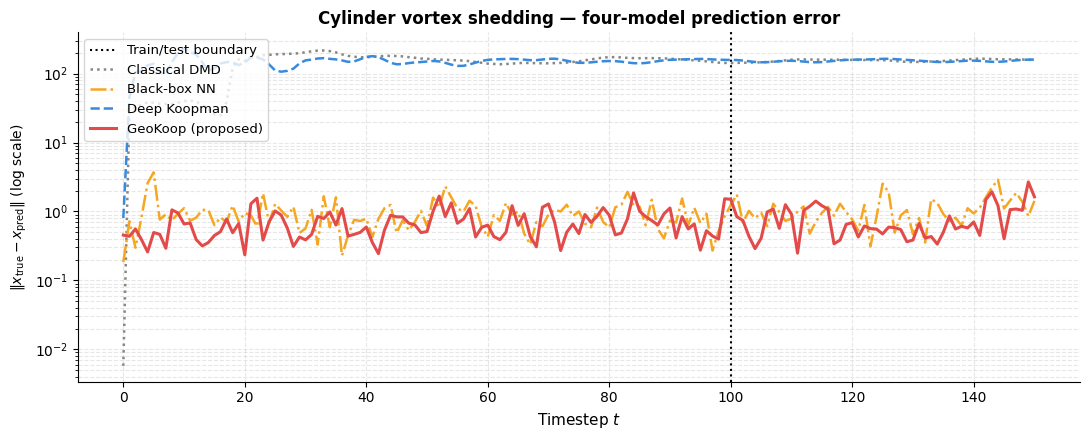

Saved cylinder_error.png


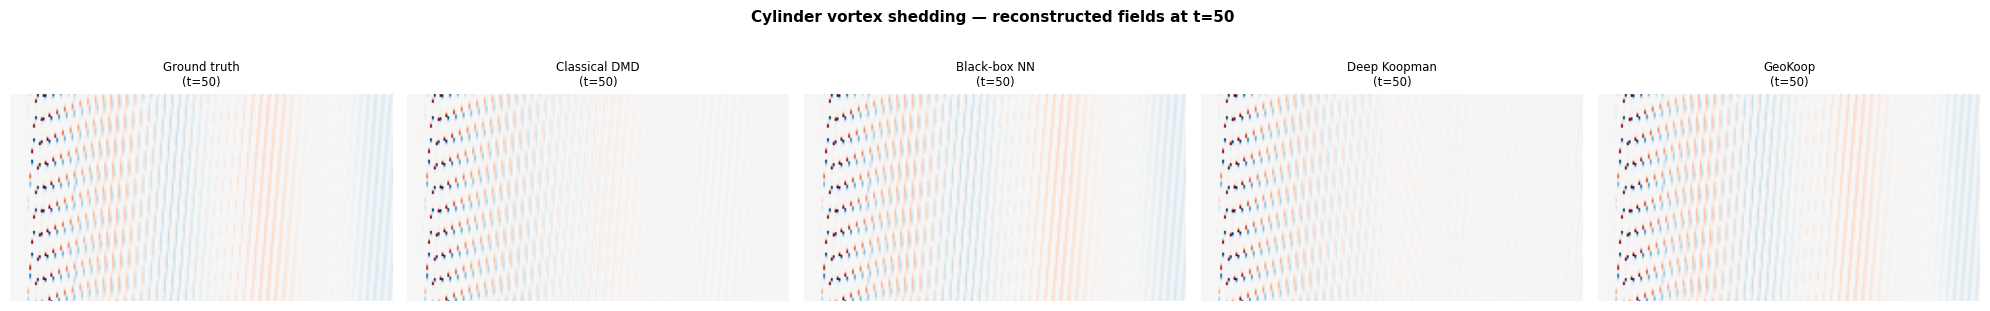

Saved cylinder_t50.png


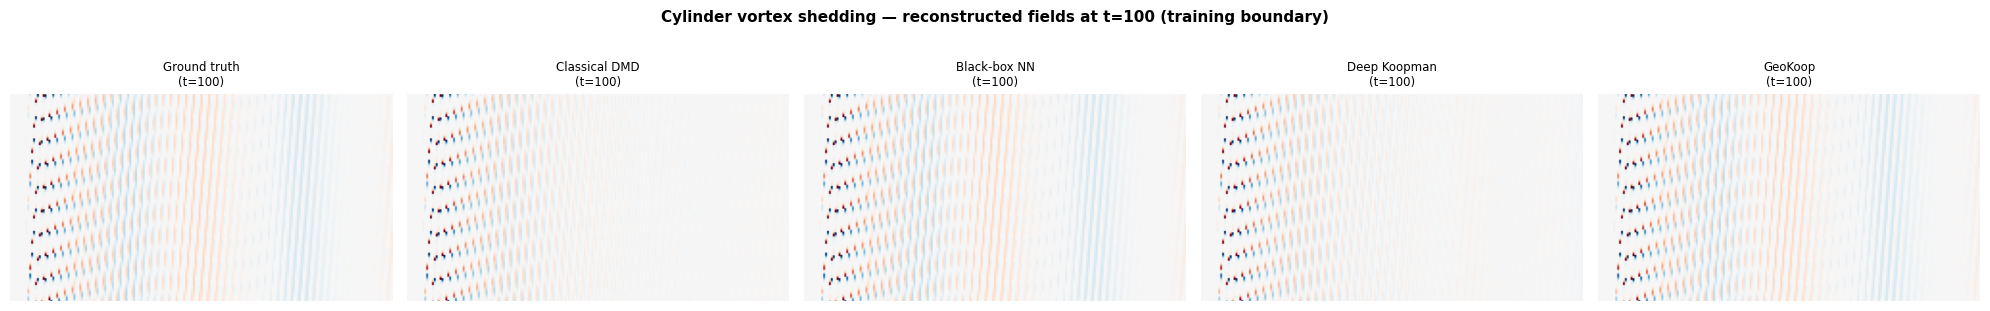

Saved cylinder_t100.png


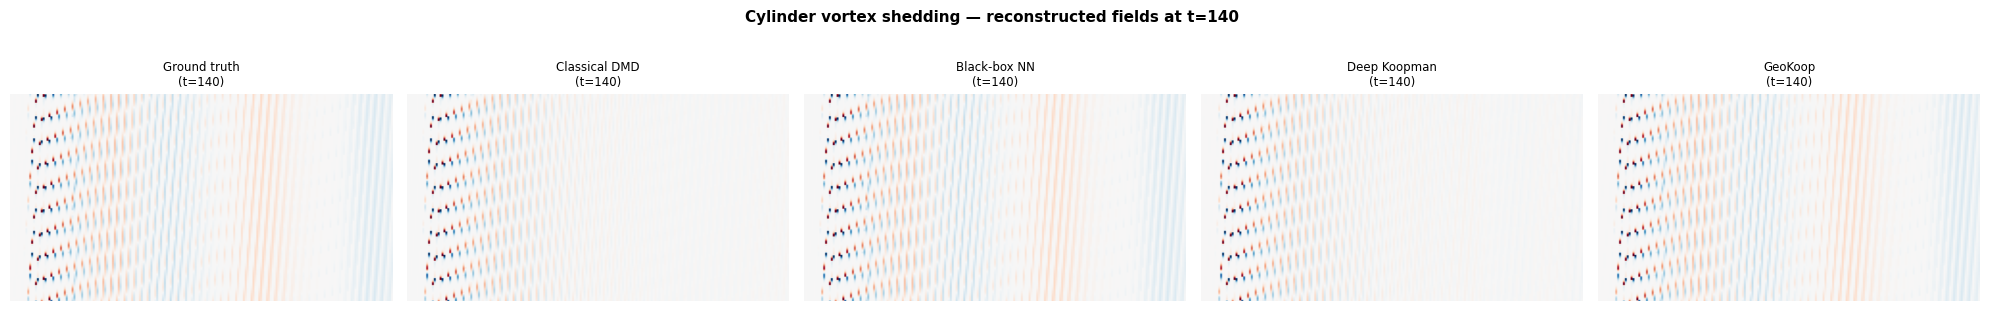

Saved cylinder_t140.png

Cylinder mean error t=100-150:
  DMD:          155.8199
  Black-box NN: 1.0892  vs GeoKoop: 1.35x
  Deep Koopman: 154.1444  vs GeoKoop: 191.69x
  GeoKoop:      0.8041


In [14]:
# Cylinder — figures (four models)
import os, shutil
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

# Training boundary for Koopman: first 100 snapshots
N_KOOPMAN_TRAIN = 100

# ── Guard: confirm all variables exist ─────────────────────────
required = {
    'err_c_dmd':  err_c_dmd,
    'err_c_bb':   err_c_bb,
    'err_c_base': err_c_base,
    'err_c_geo':  err_c_geo,
}
for name, arr in required.items():
    print(f'{name}: shape={arr.shape}, '
          f'mean(t=100-150)={arr[100:].mean():.4f}')

ts = np.arange(T_total)

# ── Figure 1: Four-model prediction error (log scale) ──────────
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvline(N_KOOPMAN_TRAIN, color='k', ls=':', lw=1.5,
           label='Train/test boundary')
ax.semilogy(ts, err_c_dmd  + 1e-8,
            color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.8,
            label='Classical DMD')
ax.semilogy(ts, err_c_bb   + 1e-8,
            color=COLORS['BlackBox'], ls=STYLES['BlackBox'], lw=1.8,
            label='Black-box NN')
ax.semilogy(ts, err_c_base + 1e-8,
            color=COLORS['Baseline'], ls=STYLES['Baseline'], lw=1.8,
            label='Deep Koopman')
ax.semilogy(ts, err_c_geo  + 1e-8,
            color=COLORS['GeoKoop'],  ls=STYLES['GeoKoop'],  lw=2.2,
            label='GeoKoop (proposed)')
ax.set_xlabel('Timestep $t$', fontsize=11)
ax.set_ylabel(r'$\|x_{\rm true} - x_{\rm pred}\|$ (log scale)',
              fontsize=10)
ax.set_title('Cylinder vortex shedding — four-model prediction error',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
for fname in ['cylinder_error.png',
              f'{OUTPUT_DIR}/cylinder_error.png',
              f'{FIG_DIR}/cylinder_error.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print('Saved cylinder_error.png')

# ── Figure 2: Vortex field snapshots — 5 columns ────────────────
for t in [50, 100, 140]:
    fig, axes = plt.subplots(1, 5, figsize=(20, 3))
    vmin = float(vort_all[:, t].min())
    vmax = float(vort_all[:, t].max())
    kw   = dict(cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')

    panels = [
        ('Ground truth',  vort_all[:, t]),
        ('Classical DMD', X_dmd_full[:, t]),
        ('Black-box NN',  X_c_bb[:, t]),
        ('Deep Koopman',  X_c_base[:, t]),
        ('GeoKoop',       X_c_geo[:, t]),
    ]
    for ax, (title, arr) in zip(axes, panels):
        ax.imshow(arr.reshape(nx, ny, order='F'), **kw)
        ax.set_title(f'{title}\n(t={t})', fontsize=8.5)
        ax.axis('off')

    boundary_label = '(training boundary)' if t == N_KOOPMAN_TRAIN else ''
    plt.suptitle(
        f'Cylinder vortex shedding — reconstructed fields at '
        f't={t} {boundary_label}',
        fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    for fname in [f'cylinder_t{t}.png',
                  f'{OUTPUT_DIR}/cylinder_t{t}.png',
                  f'{FIG_DIR}/cylinder_t{t}.png']:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved cylinder_t{t}.png')

# ── Summary stats ────────────────────────────────────────────────
print()
print('Cylinder mean error t=100-150:')
geo_mean = err_c_geo[100:].mean()
print(f'  DMD:          {err_c_dmd[100:].mean():.4f}')
print(f'  Black-box NN: {err_c_bb[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_bb[100:].mean()/geo_mean:.2f}x')
print(f'  Deep Koopman: {err_c_base[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_base[100:].mean()/geo_mean:.2f}x')
print(f'  GeoKoop:      {geo_mean:.4f}')


---
### Experiment 3 — Cylinder: 5-seed four-model rollout (`res_c`)
Mean error over the held-out window t=100–150. Resumable (the slow row).

In [15]:
# ============================================================
# Experiment 3 — Cylinder: four-model 5-seed comparison  ->  res_c
# Metric: mean rollout error over the held-out window t=100..150.
# Resumable (cylinder is the slow one); set_all_seeds for consistency.
# ============================================================
import os, json
N_SEEDS = 5

# Preserve the DMD warm-start matrix against the global-`r` clobber bug
if 'A_dmd_c_orig' not in dir():
    A_dmd_c_orig = np.array(A_dmd_c, dtype=np.float64)
r = cx_t.shape[1]          # = 32, POD-mode count (guard against later overwrite)

CKPT_CYL = f"{OUTPUT_DIR}/table3_cylinder_checkpoint.json"
cyl_ckpt = json.load(open(CKPT_CYL)) if os.path.exists(CKPT_CYL) else {}

for seed in range(N_SEEDS):
    if str(seed) in cyl_ckpt:
        print(f'Cyl s{seed}: already done — skipping'); continue
    A_dmd_c = np.array(A_dmd_c_orig, dtype=np.float64)   # restore per seed

    ae_s, kp_s = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=False)
    train_model(ae_s, kp_s, cx_t, cx_tp1, use_geo=False,
                label=f'Cyl-Base-s{seed}', epochs_p1=500, epochs_p2=3000, lam_geo=0.0)
    ae_g, kg_s = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=True)
    train_model(ae_g, kg_s, cx_t, cx_tp1, use_geo=True,
                label=f'Cyl-Geo-s{seed}', epochs_p1=500, epochs_p2=3000, lam_geo=0.0)
    ae_b = cyl_ae(C_LATENT); bb_s = BlackBoxNN(C_LATENT, hidden=64).to(device)
    train_blackbox(ae_b, bb_s, cx_t, cx_tp1, label=f'Cyl-BB-s{seed}')

    X_base_s = cyl_rollout(ae_s, kp_s)
    X_geo_s  = cyl_rollout(ae_g, kg_s)
    X_bb_s   = cyl_rollout(ae_b, bb_s)
    rec = {'dmd':  float(err_c_dmd[100:].mean()),
           'bb':   float(np.linalg.norm(vort_all - X_bb_s,   axis=0)[100:].mean()),
           'base': float(np.linalg.norm(vort_all - X_base_s, axis=0)[100:].mean()),
           'geo':  float(np.linalg.norm(vort_all - X_geo_s,  axis=0)[100:].mean())}
    cyl_ckpt[str(seed)] = rec
    tmp = CKPT_CYL + '.tmp'
    json.dump(cyl_ckpt, open(tmp, 'w'), indent=2); os.replace(tmp, CKPT_CYL)
    print(f'Cyl s{seed}: DMD={rec["dmd"]:.3f}  BB={rec["bb"]:.3f}  '
          f'Base={rec["base"]:.3f}  Geo={rec["geo"]:.3f}   [checkpoint saved]')

res_c = {k: [cyl_ckpt[str(s)][k] for s in range(N_SEEDS) if str(s) in cyl_ckpt]
         for k in ['dmd', 'bb', 'base', 'geo']}
print_5seed_summary('Cylinder', res_c, 'mean err t=100-150')
if len(res_c['geo']) < N_SEEDS:
    print(f"[!] {len(res_c['geo'])}/{N_SEEDS} cylinder seeds done — re-run to continue.")


Cyl s0: already done — skipping
Cyl s1: already done — skipping
Cyl s2: already done — skipping
Cyl s3: already done — skipping
Cyl s4: already done — skipping

Cylinder — 5-seed summary (mean err t=100-150)
DMD       : 155.7705            205.02x vs Geo   (deterministic)
BlackBox  :  0.9765 ± 0.1215     1.29x vs Geo   [0.8963 0.9273 1.0994 1.1122 0.8474]
DeepKoop  : 155.7946 ± 10.0903   205.05x vs Geo   [152.6202 172.1104 153.8218 144.522  155.8984]
GeoKoop   :  0.7598 ± 0.0570     1.00x (ref)   [0.7586 0.6817 0.7943 0.7337 0.8308]


Sampled 200 latent states, shape=(200, 4)

Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)
  ||N(z)||_F           mean=0.0499  std=0.0076
  ||J_f(z)-K||_F       mean=0.0514  std=0.0052
  ||N(z)-(J_f-K)||_F   mean=0.0226  std=0.0057
  Relative error       mean=0.4372  std=0.0885
  Element-wise Pearson r: mean=0.8954  std=0.0486  n=200

RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.


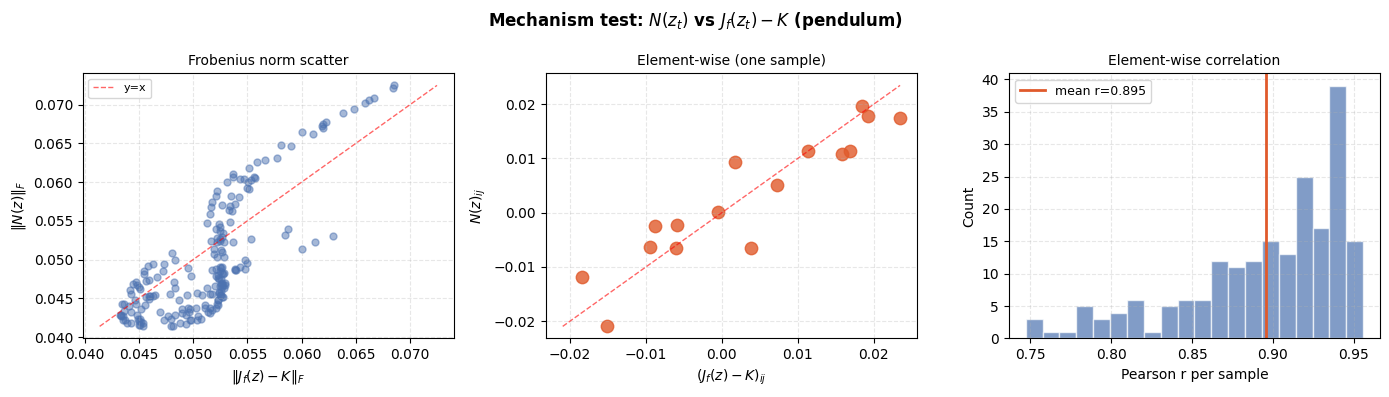

Saved pendulum_mechanism.png


In [16]:
# Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum)
# Estimate J_f(z_t) via finite differences, compare to K + N(z_t)

kg_s.eval()
ae_g.eval()
_dev = next(kg_s.parameters()).device   # get model device (cpu or cuda)

def latent_dynamics_fn(koop, z_np):
    """Apply Koopman dynamics: numpy in, numpy out. Handles GPU correctly."""
    z_t = torch.tensor(z_np, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        return koop(z_t).squeeze(0).cpu().numpy()

def finite_diff_jacobian(fn, z, eps=1e-4):
    """Estimate d x d Jacobian of fn at z via central differences."""
    d = len(z)
    J = np.zeros((d, d))
    for j in range(d):
        zp = z.copy(); zp[j] += eps
        zm = z.copy(); zm[j] -= eps
        J[:, j] = (fn(zp) - fn(zm)) / (2 * eps)
    return J

# Sample latent states from pendulum test trajectories
N_SAMPLES = 200
latent_states = []

with torch.no_grad():
    for i in range(min(N_SAMPLES, X_te_n.shape[0])):
        x_in = X_te_n[i, 0, :]
        # handle both tensor and numpy input
        if isinstance(x_in, torch.Tensor):
            x_in = x_in.float()
        else:
            x_in = torch.tensor(x_in, dtype=torch.float32)
        z = ae_g.encode(x_in.unsqueeze(0).to(_dev)).squeeze(0).cpu().numpy()
        latent_states.append(z)

latent_states = np.array(latent_states[:N_SAMPLES])
print(f"Sampled {len(latent_states)} latent states, shape={latent_states.shape}")

# K on CPU for numpy comparison
K_np = kg_s.K.detach().cpu().numpy()

def geo_dynamics(z_np):
    return latent_dynamics_fn(kg_s, z_np)

residuals    = []
N_norms      = []
Jf_K_norms   = []
correlations = []

for z in latent_states:
    # Finite-difference Jacobian
    Jf = finite_diff_jacobian(geo_dynamics, z)

    # N(z) from network — move to device, back to cpu
    z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        N_z = kg_s.N_net(z_t).view(P_LATENT, P_LATENT).cpu().numpy()

    Jf_minus_K = Jf - K_np
    residual   = N_z - Jf_minus_K

    residuals.append(np.linalg.norm(residual, 'fro'))
    N_norms.append(np.linalg.norm(N_z, 'fro'))
    Jf_K_norms.append(np.linalg.norm(Jf_minus_K, 'fro'))

    n_flat = N_z.flatten()
    j_flat = Jf_minus_K.flatten()
    if np.std(n_flat) > 1e-8 and np.std(j_flat) > 1e-8:
        correlations.append(np.corrcoef(n_flat, j_flat)[0, 1])

residuals    = np.array(residuals)
N_norms      = np.array(N_norms)
Jf_K_norms   = np.array(Jf_K_norms)
correlations = np.array(correlations)

print()
print("=" * 60)
print("Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)")
print("=" * 60)
print(f"  ||N(z)||_F           mean={N_norms.mean():.4f}  std={N_norms.std():.4f}")
print(f"  ||J_f(z)-K||_F       mean={Jf_K_norms.mean():.4f}  std={Jf_K_norms.std():.4f}")
print(f"  ||N(z)-(J_f-K)||_F   mean={residuals.mean():.4f}  std={residuals.std():.4f}")
rel_error = residuals / (Jf_K_norms + 1e-8)
print(f"  Relative error       mean={rel_error.mean():.4f}  std={rel_error.std():.4f}")
print(f"  Element-wise Pearson r: mean={correlations.mean():.4f}  "
      f"std={correlations.std():.4f}  "
      f"n={len(correlations)}")
print()
if correlations.mean() > 0.5:
    print("RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.")
elif correlations.mean() > 0.2:
    print("RESULT: MODERATE — partial support for N(z) ≈ J_f(z) - K.")
else:
    print("RESULT: WEAK — N(z) ≈ J_f(z) - K is not strongly supported.")

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$ (pendulum)",
             fontsize=12, fontweight='bold')

# Panel 1: Frobenius norm comparison
axes[0].scatter(Jf_K_norms, N_norms, alpha=0.5, s=25, color='#4C72B0')
lims = [min(Jf_K_norms.min(), N_norms.min()),
        max(Jf_K_norms.max(), N_norms.max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$", fontsize=10)
axes[0].set_ylabel(r"$\|N(z)\|_F$", fontsize=10)
axes[0].set_title("Frobenius norm scatter", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel 2: element-wise scatter (one sample)
z_s = latent_states[0]
z_t = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = kg_s.N_net(z_t).view(P_LATENT, P_LATENT).cpu().numpy()
Jf_s   = finite_diff_jacobian(geo_dynamics, z_s)
JfK_s  = Jf_s - K_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(),
                alpha=0.8, s=80, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$", fontsize=10)
axes[1].set_ylabel(r"$N(z)_{ij}$", fontsize=10)
axes[1].set_title("Element-wise (one sample)", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

# Panel 3: distribution of correlations
axes[2].hist(correlations, bins=20, color='#4C72B0',
             alpha=0.7, edgecolor='white')
axes[2].axvline(correlations.mean(), color='#E05A2B', lw=2,
                label=f'mean r={correlations.mean():.3f}')
axes[2].set_xlabel("Pearson r per sample", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].set_title("Element-wise correlation", fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['pendulum_mechanism.png',
              f'{OUTPUT_DIR}/pendulum_mechanism.png',
              f'{FIG_DIR}/pendulum_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
# Store as mech_pend for multi-system summary
mech_pend = dict(
    label=f"Pendulum (d={P_LATENT})",
    latent_dim=P_LATENT,
    n=len(latent_states),
    N_norms=N_norms,
    Jf_K_norms=Jf_K_norms,
    residuals=residuals,
    correlations=correlations,
    latent_states=latent_states,
)
print("Saved pendulum_mechanism.png")


---
## Section 7 — Physical application (cylinder)
Local stability variation along the attractor, position-dependent Koopman modes, and the spatial nonlinearity map. Saves `local_stability.png`, `position_modes.png`, `nonlinearity_map.png` for `\ref{sec:physical}`. Uses the cell-20 GeoKoop cylinder model.

Latent trajectory shape: (151, 16)
Dominant |λ(A(z_t))|: mean=0.8011  min=0.6628  max=1.0565
Global K dominant |λ|: 0.9786
||N(z_t)||_F:          mean=3.4522  std=0.2678


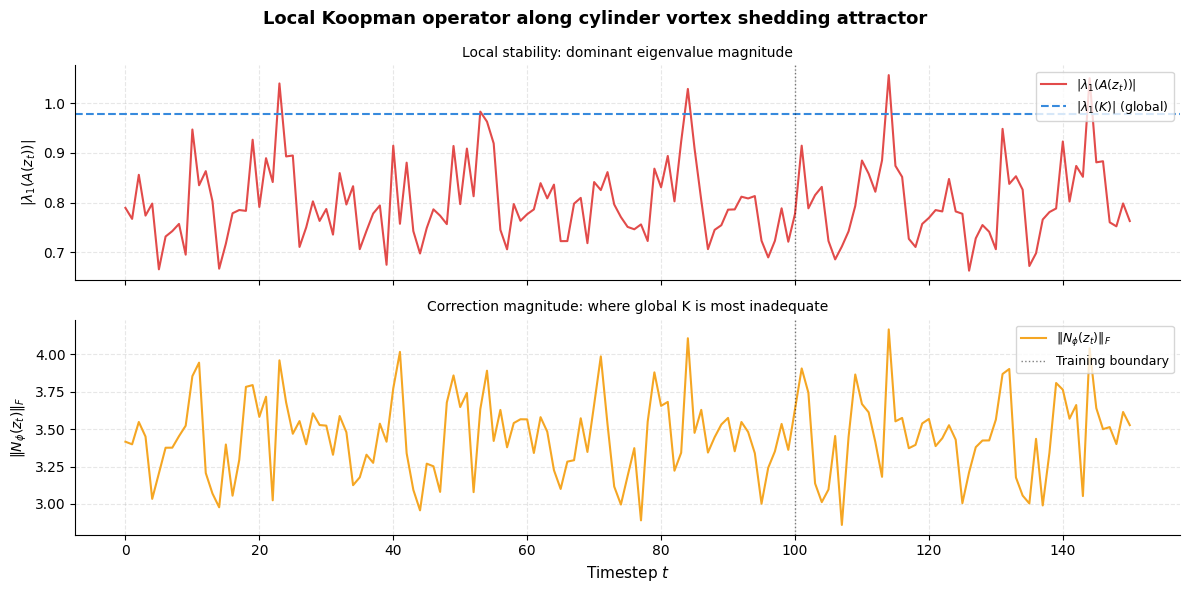

Saved local_stability.png


In [17]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
# ═══════════════════════════════════════════════════════════════════
# Figure A: Local stability analysis along the cylinder attractor
# At each timestep t, compute dominant eigenvalue of A(z_t)=K+N(z_t)
# Shows where on the attractor the local dynamics are most/least stable
# ═══════════════════════════════════════════════════════════════════
ae_c_geo.eval(); koop_c_geo.eval()

K_np = koop_c_geo.K.detach().cpu().numpy()   # (d, d) global backbone

# Roll out latent trajectory over full T_total timesteps
latent_traj = []
with torch.no_grad():
    # Encode from first snapshot of full vorticity field
    x0 = torch.tensor(X_train_n[:, 0:1].T, dtype=torch.float32).to(device)
    z  = ae_c_geo.encode(x0)   # (1, d)
    latent_traj.append(z.cpu().numpy().squeeze())
    for t in range(T_total - 1):
        z = koop_c_geo(z)
        latent_traj.append(z.cpu().numpy().squeeze())

latent_traj = np.array(latent_traj)   # (T_total, d)
print(f"Latent trajectory shape: {latent_traj.shape}")

# At each point, compute local operator A(z_t) and its dominant eigenvalue
dom_eig_mag  = []    # |lambda_1(A(z_t))|
dom_eig_ang  = []    # angle of dominant eigenvalue
local_K_norm = []    # ||N(z_t)||_F

for t in range(T_total):
    z_t = torch.tensor(latent_traj[t:t+1], dtype=torch.float32).to(device)
    with torch.no_grad():
        N_t = koop_c_geo.N_net(z_t).view(C_LATENT, C_LATENT).cpu().numpy()
    A_t  = K_np + N_t
    eigs = np.linalg.eigvals(A_t)
    eigs_sorted = eigs[np.argsort(-np.abs(eigs))]
    dom_eig_mag.append(np.abs(eigs_sorted[0]))
    dom_eig_ang.append(np.abs(np.angle(eigs_sorted[0])))
    local_K_norm.append(np.linalg.norm(N_t, "fro"))

dom_eig_mag  = np.array(dom_eig_mag)
dom_eig_ang  = np.array(dom_eig_ang)
local_K_norm = np.array(local_K_norm)

print(f"Dominant |λ(A(z_t))|: mean={dom_eig_mag.mean():.4f}  "
      f"min={dom_eig_mag.min():.4f}  max={dom_eig_mag.max():.4f}")
print(f"Global K dominant |λ|: {np.abs(np.linalg.eigvals(K_np)).max():.4f}")
print(f"||N(z_t)||_F:          mean={local_K_norm.mean():.4f}  "
      f"std={local_K_norm.std():.4f}")

# ── Figure A plot ─────────────────────────────────────────────────────────────
ts = np.arange(T_total)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Local Koopman operator along cylinder vortex shedding attractor",
             fontsize=13, fontweight="bold")

# Panel 1: dominant eigenvalue magnitude
axes[0].plot(ts, dom_eig_mag, color="#E24B4A", lw=1.5, label=r"$|\lambda_1(A(z_t))|$")
axes[0].axhline(np.abs(np.linalg.eigvals(K_np)).max(), color="#378ADD",
                ls="--", lw=1.5, label=r"$|\lambda_1(K)|$ (global)")
axes[0].axvline(n_koopman, color="k", ls=":", lw=1, alpha=0.5)
axes[0].set_ylabel(r"$|\lambda_1(A(z_t))|$", fontsize=10)
axes[0].legend(fontsize=9, loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)
axes[0].set_title("Local stability: dominant eigenvalue magnitude", fontsize=10)

# Panel 2: dominant eigenvalue angle → implied local frequency
dom_eig_ang_arr = np.array(dom_eig_ang)
# Panel 2: correction magnitude ||N(z_t)||_F
axes[1].plot(ts, local_K_norm, color="#F5A623", lw=1.5,
             label=r"$\|N_\phi(z_t)\|_F$")
axes[1].axvline(n_koopman, color="k", ls=":", lw=1, alpha=0.5,
                label="Training boundary")
axes[1].set_xlabel("Timestep $t$", fontsize=11)
axes[1].set_ylabel(r"$\|N_\phi(z_t)\|_F$", fontsize=10)
axes[1].legend(fontsize=9, loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)
axes[1].set_title("Correction magnitude: where global K is most inadequate",
                  fontsize=10)

plt.tight_layout()
for fname in ["local_stability.png",
              f"{OUTPUT_DIR}/local_stability.png",
              f"{FIG_DIR}/local_stability.png"]:
    plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print("Saved local_stability.png")


Max correction at t=84: ||N||_F=4.1067
Min correction at t=77: ||N||_F=2.8905


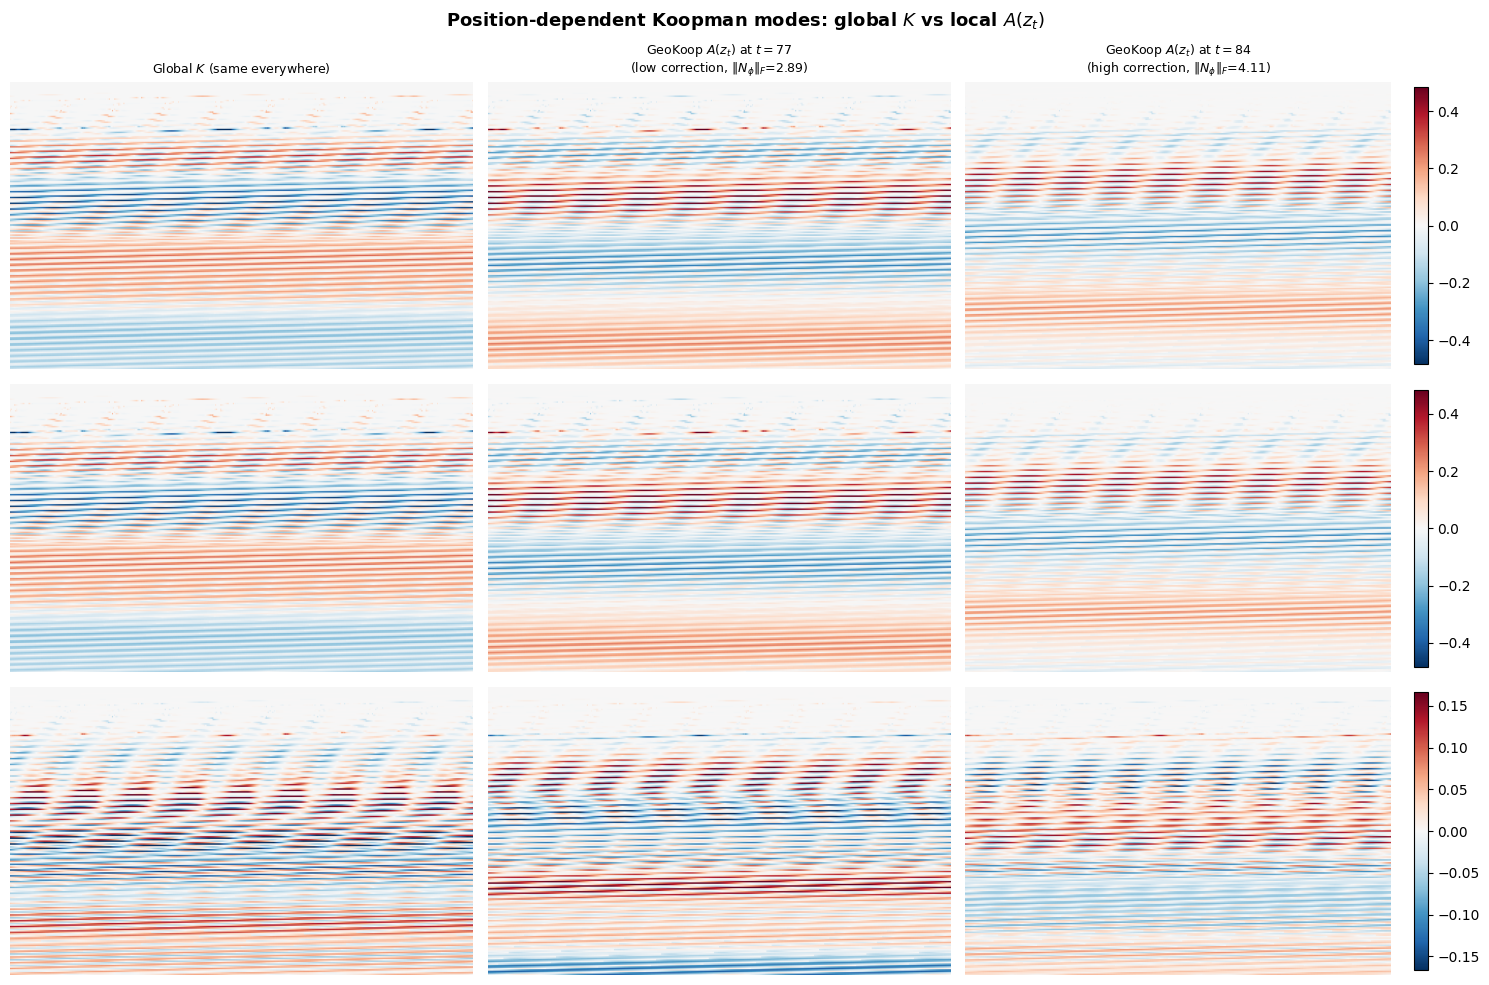

Saved position_modes.png

Key result: compare columns 2 and 3 vs column 1.
If modes differ between columns → local operator captures
position-dependent physics that global K averages over.


In [18]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
# ═══════════════════════════════════════════════════════════════════
# Figure B: Position-dependent Koopman modes
# Compare dominant Koopman modes at two attractor points:
#   t_top = timestep near peak of shedding cycle
#   t_bot = timestep near trough of shedding cycle
# Global K gives same modes everywhere; GeoKoop gives different modes
# ═══════════════════════════════════════════════════════════════════

# Find two contrasting attractor points
# Use ||N(z_t)||_F to find high and low correction regions
t_max_N = int(np.argmax(local_K_norm[:n_koopman]))   # largest correction
t_min_N = int(np.argmin(local_K_norm[:n_koopman]))   # smallest correction
print(f"Max correction at t={t_max_N}: ||N||_F={local_K_norm[t_max_N]:.4f}")
print(f"Min correction at t={t_min_N}: ||N||_F={local_K_norm[t_min_N]:.4f}")

def get_local_modes(t_idx, n_modes=3):
    """Compute top n_modes dominant Koopman modes of A(z_t) in physical space."""
    z_t = torch.tensor(latent_traj[t_idx:t_idx+1],
                        dtype=torch.float32).to(device)
    with torch.no_grad():
        N_t  = koop_c_geo.N_net(z_t).view(C_LATENT, C_LATENT).cpu().numpy()
    A_t  = K_np + N_t
    eigs, evecs = np.linalg.eig(A_t)   # evecs: columns are right eigenvectors
    # Sort by magnitude
    idx  = np.argsort(-np.abs(eigs))
    eigs = eigs[idx]; evecs = evecs[:, idx]

    # Decode eigenvectors to physical space via decoder Jacobian (linear approx)
    # Use finite difference: decode(z + eps*v) - decode(z) / eps
    eps  = 1e-3
    z_np = latent_traj[t_idx]
    modes_phys = []
    for k in range(n_modes):
        v    = evecs[:, k].real
        zp   = torch.tensor((z_np + eps*v)[None], dtype=torch.float32).to(device)
        zm   = torch.tensor((z_np - eps*v)[None], dtype=torch.float32).to(device)
        with torch.no_grad():
            mode_phys = ((ae_c_geo.decode(zp) - ae_c_geo.decode(zm))
                         / (2*eps)).cpu().numpy().squeeze()
        # Map from r=32 POD space back to physical space
        mode_full = U_svd[:, :r] @ (mode_phys * C_std.squeeze() + 0)
        modes_phys.append(mode_full.reshape(nx, ny, order="F"))
    return eigs, modes_phys

eigs_max, modes_max = get_local_modes(t_max_N)
eigs_min, modes_min = get_local_modes(t_min_N)

# Global K modes (same everywhere)
eigs_K, evecs_K = np.linalg.eig(K_np)
idx_K = np.argsort(-np.abs(eigs_K))
eigs_K = eigs_K[idx_K]; evecs_K = evecs_K[:, idx_K]
z0 = torch.tensor(latent_traj[50:51], dtype=torch.float32).to(device)
modes_K = []
eps = 1e-3
z_np0 = latent_traj[50]
for k in range(3):
    v    = evecs_K[:, k].real
    zp   = torch.tensor((z_np0 + eps*v)[None], dtype=torch.float32).to(device)
    zm   = torch.tensor((z_np0 - eps*v)[None], dtype=torch.float32).to(device)
    with torch.no_grad():
        m = ((ae_c_geo.decode(zp) - ae_c_geo.decode(zm))/(2*eps)
             ).cpu().numpy().squeeze()
    mode_full = U_svd[:, :r] @ (m * C_std.squeeze())
    modes_K.append(mode_full.reshape(nx, ny, order="F"))

# ── Figure B plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(
    "Position-dependent Koopman modes: global $K$ vs local $A(z_t)$",
    fontsize=13, fontweight="bold")

col_titles = [
    "Global $K$ (same everywhere)",
    f"GeoKoop $A(z_t)$ at $t={t_min_N}$\n"
    f"(low correction, $\\|N_\\phi\\|_F$={local_K_norm[t_min_N]:.2f})",
    f"GeoKoop $A(z_t)$ at $t={t_max_N}$\n"
    f"(high correction, $\\|N_\\phi\\|_F$={local_K_norm[t_max_N]:.2f})",
]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=9)

for k in range(3):
    vmax = max(np.abs(modes_K[k]).max(),
               np.abs(modes_max[k]).max(),
               np.abs(modes_min[k]).max()) * 0.7
    kw = dict(cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

    axes[k, 0].imshow(modes_K[k].T,   **kw)
    axes[k, 1].imshow(modes_min[k].T, **kw)
    im = axes[k, 2].imshow(modes_max[k].T, **kw)

    axes[k, 0].set_ylabel(f"Mode {k+1}\n"
                           f"|λ|={np.abs(eigs_K[k]):.3f}", fontsize=8)
    for j in range(3): axes[k, j].axis("off")
    plt.colorbar(im, ax=axes[k, 2], fraction=0.03)

plt.tight_layout()
for fname in ["position_modes.png",
              f"{OUTPUT_DIR}/position_modes.png",
              f"{FIG_DIR}/position_modes.png"]:
    plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print("Saved position_modes.png")
print()
print("Key result: compare columns 2 and 3 vs column 1.")
print("If modes differ between columns → local operator captures")
print("position-dependent physics that global K averages over.")


---
## Mechanism Test — Cylinder (d=16)
Test N(z) ≈ J_f(z) - K on the cylinder vortex shedding system.
Finite-difference Jacobian in the 16-dimensional latent space.



Mechanism test: N(z) ≈ J_f(z)-K  [Cylinder (d=16)]
  Samples : 100  (latent d=16)
  ||N(z)||_F        mean=3.4446  std=0.2583
  ||J_f-K||_F       mean=3.9918  std=0.2602
  ||N-(J_f-K)||_F   mean=1.5505  std=0.1843
  Relative error    mean=0.3895  std=0.0488
  Pearson r         mean=0.9216  std=0.0215  n=100
  RESULT: STRONG


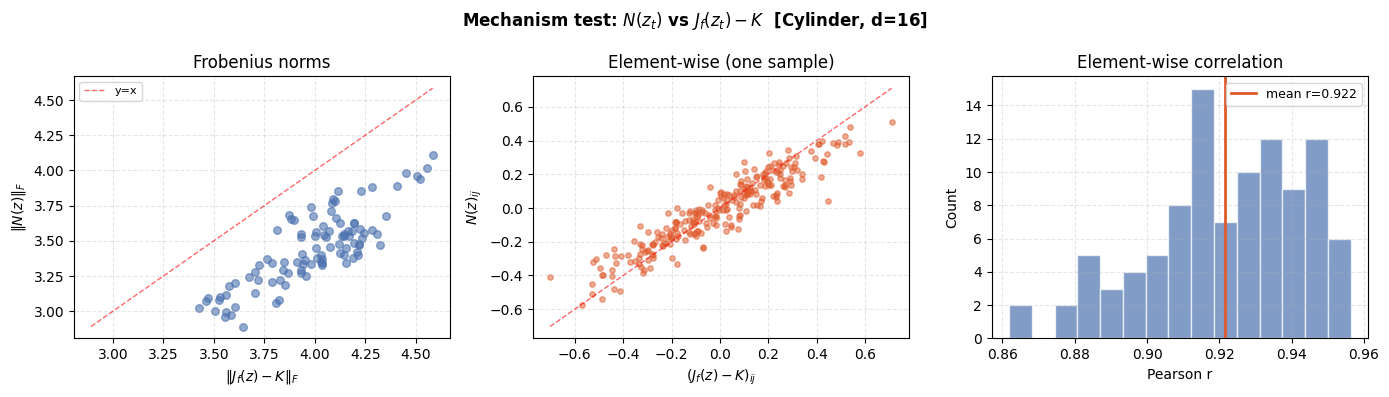

Saved cylinder_mechanism.png


In [19]:
# Mechanism test — Cylinder (d=16)
# Sample latent states from cylinder training rollout
C_MECH_SAMPLES = 100   # fewer samples — d=16 so FD has 32 passes each

# Build sample inputs from cylinder training snapshots
cyl_x_samples = (X_train_n.T)[:C_MECH_SAMPLES]  # (N, r=32) normalised

K_cyl_np = koop_c_geo.K.detach().cpu().numpy()

mech_cyl = run_mechanism_test(
    koop       = koop_c_geo,
    ae         = ae_c_geo,
    K_np       = K_cyl_np,
    latent_dim = C_LATENT,
    x_samples  = cyl_x_samples,
    label      = f"Cylinder (d={C_LATENT})",
    n_samples  = C_MECH_SAMPLES,
)

# ── Figure: cylinder mechanism ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$  "
             f"[Cylinder, d={C_LATENT}]",
             fontsize=12, fontweight='bold')

r_cyl = mech_cyl["correlations"]
axes[0].scatter(mech_cyl["Jf_K_norms"], mech_cyl["N_norms"],
                alpha=0.6, s=30, color='#4C72B0')
lims = [min(mech_cyl["Jf_K_norms"].min(), mech_cyl["N_norms"].min()),
        max(mech_cyl["Jf_K_norms"].max(), mech_cyl["N_norms"].max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$"); axes[0].set_ylabel(r"$\|N(z)\|_F$")
axes[0].set_title("Frobenius norms"); axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

z_s   = mech_cyl["latent_states"][0]
_dev  = get_device(koop_c_geo)
dyn_c = make_latent_dynamics_fn(koop_c_geo)
z_t   = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = koop_c_geo.N_net(z_t).view(C_LATENT, C_LATENT).cpu().numpy()
Jf_s  = finite_diff_jacobian(dyn_c, z_s)
JfK_s = Jf_s - K_cyl_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(), alpha=0.5, s=15, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$"); axes[1].set_ylabel(r"$N(z)_{ij}$")
axes[1].set_title("Element-wise (one sample)")
axes[1].grid(True, linestyle='--', alpha=0.3)

axes[2].hist(r_cyl, bins=15, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[2].axvline(r_cyl.mean(), color='#E05A2B', lw=2,
                label=f'mean r={r_cyl.mean():.3f}')
axes[2].set_xlabel("Pearson r"); axes[2].set_ylabel("Count")
axes[2].set_title("Element-wise correlation"); axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['cylinder_mechanism.png',
              f'{OUTPUT_DIR}/cylinder_mechanism.png',
              f'{FIG_DIR}/cylinder_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved cylinder_mechanism.png")


---
## Experiment 5 — Van der Pol Oscillator
Nonlinear oscillator with limit-cycle attractor and nonlinear damping:
  x'' - μ(1-x²)x' + x = 0,  μ=1.5
Two-dimensional state [x, x'], dt=0.05, T=200 steps.


VdP data: (80, 500, 2)  train pairs: torch.Size([39920, 2])
Training VdP Black-box...
VdP-BB ep=   0 | rec=1.00726  dyn=0.06606
VdP-BB ep= 500 | rec=0.00013  dyn=0.00012
VdP-BB ep=1000 | rec=0.00033  dyn=0.00009
VdP-BB ep=1500 | rec=0.00005  dyn=0.00006
VdP-BB ep=2000 | rec=0.00001  dyn=0.00004
Training VdP Deep Koopman...
VdP-Base ep=   0 | rec=1.01496  dyn=0.00011
VdP-Base ep= 500 | rec=0.00016  dyn=0.00039
VdP-Base ep=1000 | rec=0.00002  dyn=0.00042
VdP-Base ep=1500 | rec=0.00001  dyn=0.00031
VdP-Base ep=2000 | rec=0.00001  dyn=0.00024
Training VdP GeoKoop...
VdP-Geo ep=   0 | rec=0.99123  dyn=0.00007
VdP-Geo ep= 500 | rec=0.00018  dyn=0.00000
VdP-Geo ep=1000 | rec=0.00001  dyn=0.00031
VdP-Geo ep=1500 | rec=0.00001  dyn=0.00024
VdP-Geo ep=2000 | rec=0.00002  dyn=0.00023
VdP mean error (steps 50-200):
  Black-box:    2.9005  vs GeoKoop: 1.20x
  Deep Koopman: 2.3629  vs GeoKoop: 0.98x
  GeoKoop:      2.4180

Mechanism test: N(z) ≈ J_f(z)-K  [Van der Pol (d=4)]
  Samples : 200  (latent

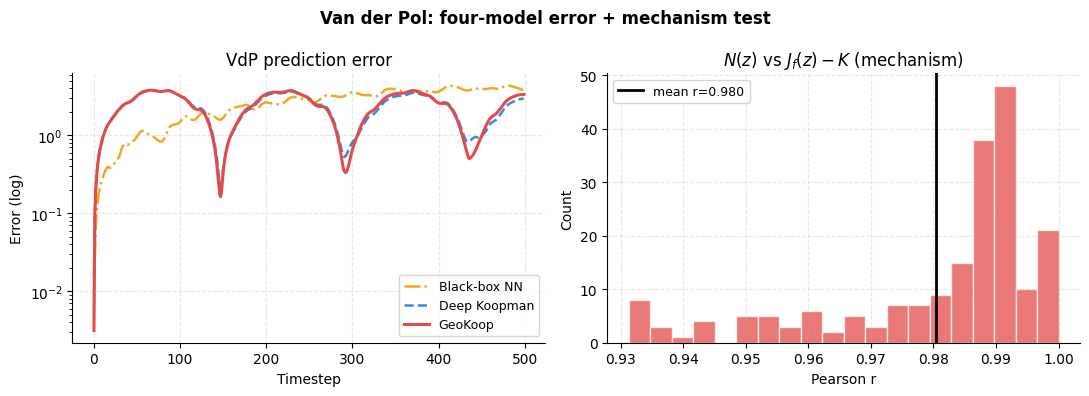

Saved vdp_results.png


In [20]:
# Van der Pol — generate data, train all four models, mechanism test
from scipy.integrate import solve_ivp

# ── Generate Van der Pol data ───────────────────────────────────
VDP_MU    = 1.5
VDP_DT    = 0.05
VDP_T     = 500      # total steps
VDP_BURN  = 100      # burn-in
VDP_TRAIN = 300
VDP_LATENT= 4

def vdp_rhs(t, y, mu=VDP_MU):
    x, v = y
    return [v, mu*(1 - x**2)*v - x]

np.random.seed(0)
x0s = []
for _ in range(80):    # 80 trajectories
    r  = np.random.uniform(0.5, 2.5)
    th = np.random.uniform(0, 2*np.pi)
    x0s.append([r*np.cos(th), r*np.sin(th)])

vdp_trajs = []
for x0 in x0s:
    sol = solve_ivp(vdp_rhs, [0, (VDP_T+VDP_BURN)*VDP_DT], x0,
                    t_eval=np.arange(VDP_T+VDP_BURN)*VDP_DT,
                    method='RK45', rtol=1e-8, atol=1e-10)
    vdp_trajs.append(sol.y.T[VDP_BURN:])  # (VDP_T, 2)

vdp_data = np.stack(vdp_trajs)   # (80, VDP_T, 2)
vdp_mu_  = vdp_data[:, :VDP_TRAIN].mean(axis=(0,1))
vdp_sig_ = vdp_data[:, :VDP_TRAIN].std(axis=(0,1)) + 1e-8
vdp_n    = (vdp_data - vdp_mu_) / vdp_sig_

# Trajectory pairs for training
vdp_xt   = torch.tensor(vdp_n[:, :-1].reshape(-1,2), dtype=torch.float32)
vdp_xtp1 = torch.tensor(vdp_n[:, 1:].reshape(-1,2),  dtype=torch.float32)
print(f"VdP data: {vdp_data.shape}  train pairs: {vdp_xt.shape}")

# ── VdP Koopman model ───────────────────────────────────────────
class KoopmanVdP(nn.Module):
    def __init__(self, d=VDP_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d,d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d,32), nn.Tanh(),
                nn.Linear(32,32), nn.Tanh(),
                nn.Linear(32, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)
    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_vdp(ae, koop_or_bb, label, use_geo=True, is_bb=False,
              epochs_p1=500, epochs_p2=2000, lam_geo=0.0,
              rollout_steps=20, lr=1e-3):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    xt_d, xtp1_d = vdp_xt.to(device), vdp_xtp1.to(device)
    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        loss_rec = ((xt_d - ae.decode(z_t))**2).mean()
        z_pred   = koop_or_bb(z_t)
        loss_dyn = ((z_tp1 - z_pred)**2).mean()
        if epoch >= epochs_p1 and not is_bb:
            zr = z_t.clone()
            for _ in range(rollout_steps): zr = koop_or_bb(zr)
            loss_roll = ((z_tp1 - zr)**2).mean()
        else:
            loss_roll = torch.tensor(0., device=device)
        eig_loss = torch.tensor(0., device=device)
        if not is_bb:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01*((eigs.abs()-1)**2).mean()
        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 500 == 0:
            print(f"{label} ep={epoch:4d} | "
                  f"rec={loss_rec.item():.5f}  dyn={loss_dyn.item():.5f}")

# ── Train all four VdP models ───────────────────────────────────
vdp_ae_bb   = AE(2, VDP_LATENT).to(device)
vdp_ae_base = AE(2, VDP_LATENT).to(device)
vdp_ae_geo  = AE(2, VDP_LATENT).to(device)
vdp_bb      = BlackBoxNN(VDP_LATENT, hidden=32).to(device)
vdp_base    = KoopmanVdP(VDP_LATENT, use_geo=False).to(device)
vdp_geo     = KoopmanVdP(VDP_LATENT, use_geo=True).to(device)

print("Training VdP Black-box...")
train_vdp(vdp_ae_bb,   vdp_bb,   "VdP-BB",   use_geo=False, is_bb=True)
print("Training VdP Deep Koopman...")
train_vdp(vdp_ae_base, vdp_base, "VdP-Base", use_geo=False)
print("Training VdP GeoKoop...")
train_vdp(vdp_ae_geo,  vdp_geo,  "VdP-Geo",  use_geo=True)

# ── VdP rollout errors ──────────────────────────────────────────
@torch.no_grad()
def vdp_rollout(ae, dyn, traj_np):
    """Roll out from traj_np[0] for len(traj_np) steps."""
    ae.eval(); dyn.eval()
    z = ae.encode(torch.tensor(traj_np[0:1], dtype=torch.float32).to(device))
    preds = [ae.decode(z).cpu().numpy()]
    for _ in range(len(traj_np)-1):
        z = dyn(z)
        preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds) * vdp_sig_ + vdp_mu_

# Use last 10 trajectories as test
test_trajs = vdp_data[70:]
err_vdp_bb   = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_bb,   vdp_bb,   (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)
err_vdp_base = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_base, vdp_base, (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)
err_vdp_geo  = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_geo,  vdp_geo,  (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)

print(f"VdP mean error (steps 50-200):")
geo_m = err_vdp_geo[50:].mean()
print(f"  Black-box:    {err_vdp_bb[50:].mean():.4f}  vs GeoKoop: {err_vdp_bb[50:].mean()/geo_m:.2f}x")
print(f"  Deep Koopman: {err_vdp_base[50:].mean():.4f}  vs GeoKoop: {err_vdp_base[50:].mean()/geo_m:.2f}x")
print(f"  GeoKoop:      {geo_m:.4f}")

# ── Mechanism test ──────────────────────────────────────────────
vdp_x_samples = vdp_n[:70, :VDP_TRAIN].reshape(-1,2)[:200]
K_vdp_np      = vdp_geo.K.detach().cpu().numpy()

mech_vdp = run_mechanism_test(
    koop       = vdp_geo,
    ae         = vdp_ae_geo,
    K_np       = K_vdp_np,
    latent_dim = VDP_LATENT,
    x_samples  = vdp_x_samples,
    label      = f"Van der Pol (d={VDP_LATENT})",
    n_samples  = 200,
)

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Van der Pol: four-model error + mechanism test",
             fontsize=12, fontweight='bold')
ts = np.arange(VDP_T)
axes[0].semilogy(ts, err_vdp_bb+1e-8,   color=COLORS['BlackBox'],
                 ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
axes[0].semilogy(ts, err_vdp_base+1e-8, color=COLORS['Baseline'],
                 ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
axes[0].semilogy(ts, err_vdp_geo+1e-8,  color=COLORS['GeoKoop'],
                 ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Error (log)')
axes[0].set_title('VdP prediction error'); axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

r_vdp = mech_vdp["correlations"]
axes[1].hist(r_vdp, bins=20, color=COLORS['GeoKoop'], alpha=0.75, edgecolor='white')
axes[1].axvline(r_vdp.mean(), color='k', lw=2,
                label=f'mean r={r_vdp.mean():.3f}')
axes[1].set_xlabel('Pearson r'); axes[1].set_ylabel('Count')
axes[1].set_title(r'$N(z)$ vs $J_f(z)-K$ (mechanism)')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['vdp_results.png',
              f'{OUTPUT_DIR}/vdp_results.png',
              f'{FIG_DIR}/vdp_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved vdp_results.png")


---

## Section 8.2 — Nonlinearity map in phase space (5-seed, Van der Pol)

Because the mechanism test gives $N(z)\approx J_f(z)-K$, the Frobenius norm $\|N(z)\|_F$ is a **phase-space** map of where the single global Koopman backbone $K$ is locally insufficient — small $\|N\|_F$ = well described by $K$ alone, large $\|N\|_F$ = where genuine nonlinearity concentrates.

This is computed directly in latent space (a forward pass of $N_\phi$), so it needs **no extra training and no decoder/POD projection** — it avoids the basis artifacts of the old physical-space map. Van der Pol is the showcase: $\|N\|_F$ should peak in the **fast relaxation segments** of the limit cycle and nearly vanish on the slow branches. The cell below verifies this across 5 seeds (each profile normalised by its own peak) and reports the $\|N\|$–speed correlation as an automatic check.


Loaded cached 5-seed ||N|| profiles: (5, 2000)


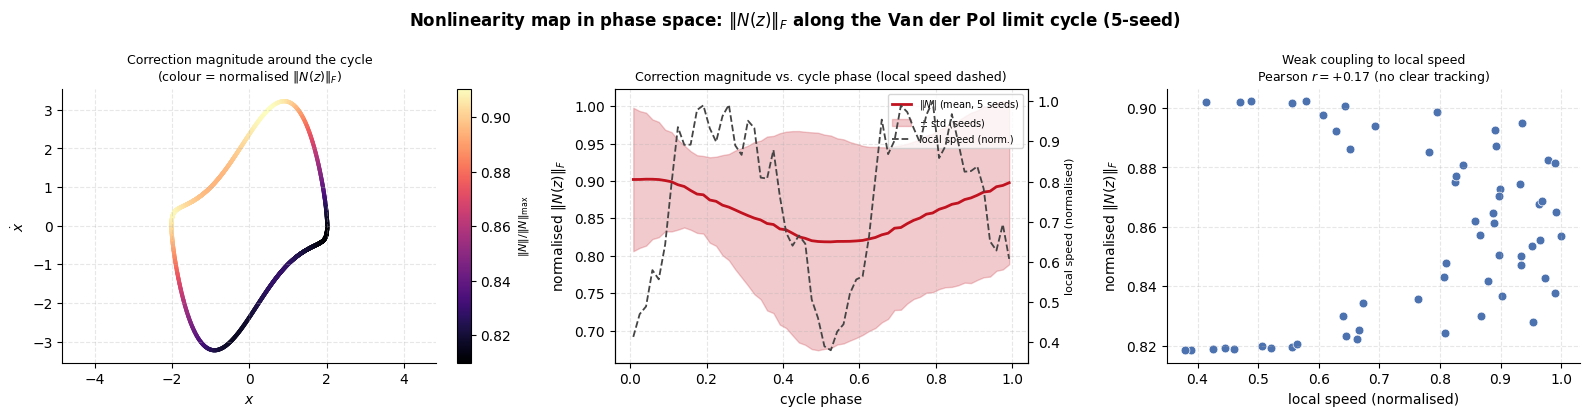

Saved vdp_nonlinearity_map.png

||N|| vs local speed (phase-binned)  Pearson r = +0.168
||N|| peak at phase ~ 0.04;  quietest segment = 0.82 of peak
VERDICT: localisation WEAKER than predicted -- inspect the phase profile
         before relying on the fast-segment narrative.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 8.2  Nonlinearity map in PHASE SPACE (5-seed) — Van der Pol showcase
#
# The mechanism test established N(z) ~= J_f(z) - K, so ||N(z)||_F is a faithful,
# artifact-free measure of where the single global operator K is locally
# insufficient -- i.e. where genuine nonlinearity concentrates.  Unlike a
# physical-space (decoder-projected) map, ||N(z)||_F is a DIRECT latent-space
# quantity: no decoder Jacobian, no POD truncation, no basis artifact.
#
# VdP is the natural showcase: the nonlinear damping mu*(1-x^2)*v concentrates
# the action in the fast relaxation segments of the limit cycle.  We therefore
# PREDICT ||N|| peaks there and nearly vanishes on the slow branches, and we test
# that across 5 seeds.  Each seed's profile is normalised by its own peak: the
# absolute ||N|| scale is not identified consistently across seeds (the mechanism
# test showed ||N|| undershoots ||J_f-K|| by a seed-varying amount), but the
# LOCALISATION SHAPE is the scientific claim, and it should be seed-robust.
#
# Requires (all defined earlier): AE, KoopmanVdP, train_vdp, vdp_rhs, solve_ivp,
# VDP_LATENT, VDP_MU, vdp_mu_, vdp_sig_, device, OUTPUT_DIR, FIG_DIR.
# ══════════════════════════════════════════════════════════════════════════════
import os, numpy as np, torch
import matplotlib.pyplot as plt

VDP_NL_SEEDS = 5
VDP_NL_CACHE = f"{OUTPUT_DIR}/vdp_nonlinearity_5seed.npz"

# ── 1. One clean reference limit cycle (deterministic, post-transient) ─────────
_ref_dt, _ref_tmax = 0.02, 60.0
_sol = solve_ivp(vdp_rhs, [0, _ref_tmax], [2.0, 0.0],
                 t_eval=np.arange(0, _ref_tmax, _ref_dt),
                 method="RK45", rtol=1e-9, atol=1e-11)
_X    = _sol.y.T                              # (T, 2) raw [x, v]
_burn = int(20.0 / _ref_dt)                   # drop transient -> on the limit cycle
X_ref   = _X[_burn:]                          # (T, 2)
X_ref_n = (X_ref - vdp_mu_) / vdp_sig_        # normalise the way the AE expects

# local speed |d/dt (x,v)| along the cycle = how "fast" the dynamics move
speed = np.linalg.norm(np.gradient(X_ref, _ref_dt, axis=0), axis=1)

# cycle phase in [0,1) from the dominant frequency of x(t)
_x     = X_ref[:, 0] - X_ref[:, 0].mean()
_freqs = np.fft.rfftfreq(len(_x), d=_ref_dt)
_dom   = _freqs[1:][np.argmax(np.abs(np.fft.rfft(_x))[1:])]
_period_steps = (1.0 / _dom) / _ref_dt
phase = (np.arange(len(X_ref)) / _period_steps) % 1.0

# ── 2. ||N(z_t)||_F along the reference cycle for each of 5 seeds ──────────────
def _vdp_N_profile(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    ae  = AE(2, VDP_LATENT).to(device)
    geo = KoopmanVdP(VDP_LATENT, use_geo=True).to(device)
    train_vdp(ae, geo, f"VdP-NL-s{seed}", use_geo=True)
    ae.eval(); geo.eval()
    with torch.no_grad():
        z   = ae.encode(torch.tensor(X_ref_n, dtype=torch.float32).to(device))
        N   = geo.N_net(z).view(z.shape[0], VDP_LATENT, VDP_LATENT)
        nrm = torch.sqrt((N ** 2).sum(dim=(-2, -1))).cpu().numpy()  # (T,) Frobenius
    return nrm

if os.path.exists(VDP_NL_CACHE):
    _c = np.load(VDP_NL_CACHE)
    N_prof = _c["N_prof"]
    print(f"Loaded cached 5-seed ||N|| profiles: {N_prof.shape}")
else:
    N_prof = np.stack([_vdp_N_profile(s) for s in range(VDP_NL_SEEDS)])  # (S, T)
    np.savez(VDP_NL_CACHE, N_prof=N_prof, X_ref=X_ref, speed=speed, phase=phase)
    print(f"Computed & cached 5-seed ||N|| profiles: {N_prof.shape}")

# per-seed normalise by each seed's own max (keeps "near-vanishing" honest)
N_norm = N_prof / N_prof.max(axis=1, keepdims=True)
N_mean = N_norm.mean(axis=0)                   # (T,)

# ── 3. Bin by phase -> clean single-period profile (mean ± std over seeds) ─────
nbins = 60
edges = np.linspace(0, 1, nbins + 1)
ctr   = 0.5 * (edges[:-1] + edges[1:])
bi    = np.clip(np.digitize(phase, edges) - 1, 0, nbins - 1)

def _bin_mean(v):
    out = np.full(nbins, np.nan)
    for b in range(nbins):
        m = bi == b
        if m.any():
            out[b] = v[m].mean()
    return out

# per-seed phase profiles, then mean/std ACROSS seeds at each phase bin
N_ph_seed = np.stack([_bin_mean(N_norm[s]) for s in range(VDP_NL_SEEDS)])  # (S, nbins)
N_ph_mean = np.nanmean(N_ph_seed, axis=0)
N_ph_std  = np.nanstd(N_ph_seed, axis=0)
speed_ph  = _bin_mean(speed)
speed_ph  = speed_ph / np.nanmax(speed_ph)

# verdict: does ||N|| track the fast segments?
_ok      = np.isfinite(N_ph_mean) & np.isfinite(speed_ph)
r_speed  = np.corrcoef(N_ph_mean[_ok], speed_ph[_ok])[0, 1]
peak_ph  = ctr[np.nanargmax(N_ph_mean)]
slow_fr  = np.nanmin(N_ph_mean)               # quietest segment, as fraction of peak

# ── 4. Figure ─────────────────────────────────────────────────────────────────
C_HOT = "#C1121F"
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle(r"Nonlinearity map in phase space: $\|N(z)\|_F$ along the Van der Pol "
             r"limit cycle (5-seed)", fontsize=12, fontweight="bold")

# Panel 1: phase portrait coloured by mean normalised ||N||
sc = axes[0].scatter(X_ref[:, 0], X_ref[:, 1], c=N_mean, cmap="magma",
                     s=9, linewidths=0)
axes[0].set_xlabel(r"$x$"); axes[0].set_ylabel(r"$\dot{x}$")
axes[0].set_title("Correction magnitude around the cycle\n"
                  r"(colour = normalised $\|N(z)\|_F$)", fontsize=9)
cb = plt.colorbar(sc, ax=axes[0], fraction=0.046)
cb.set_label(r"$\|N\|/\|N\|_{\max}$", fontsize=8)
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].grid(True, ls="--", alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: ||N|| vs phase (mean +/- std across seeds), local speed overlaid
axes[1].plot(ctr, N_ph_mean, color=C_HOT, lw=2.0, label=r"$\|N\|$ (mean, 5 seeds)")
axes[1].fill_between(ctr, N_ph_mean - N_ph_std, N_ph_mean + N_ph_std,
                     color=C_HOT, alpha=0.22, label=r"$\pm$ std (seeds)")
ax2 = axes[1].twinx()
ax2.plot(ctr, speed_ph, color="#444444", lw=1.3, ls="--",
         label="local speed (norm.)")
ax2.set_ylabel("local speed (normalised)", fontsize=8)
axes[1].set_xlabel("cycle phase"); axes[1].set_ylabel(r"normalised $\|N(z)\|_F$")
axes[1].set_title("Correction magnitude vs. cycle phase (local speed dashed)",
                  fontsize=9)
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, fontsize=7, loc="upper right")
axes[1].grid(True, ls="--", alpha=0.3)
axes[1].spines[["top"]].set_visible(False)

# Panel 3: ||N|| vs local speed (quantitative localisation)
axes[2].scatter(speed_ph[_ok], N_ph_mean[_ok], s=40, color="#4C72B0",
                edgecolor="white", linewidth=0.5)
axes[2].set_xlabel("local speed (normalised)")
axes[2].set_ylabel(r"normalised $\|N(z)\|_F$")
axes[2].set_title(f"Weak coupling to local speed\nPearson "
                  f"$r = {r_speed:+.2f}$ (no clear tracking)", fontsize=9)
axes[2].grid(True, ls="--", alpha=0.3)
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
for fname in ["vdp_nonlinearity_map.png",
              f"{OUTPUT_DIR}/vdp_nonlinearity_map.png",
              f"{FIG_DIR}/vdp_nonlinearity_map.png"]:
    plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()

print("Saved vdp_nonlinearity_map.png")
print()
print(f"||N|| vs local speed (phase-binned)  Pearson r = {r_speed:+.3f}")
print(f"||N|| peak at phase ~ {peak_ph:.2f};  quietest segment = "
      f"{slow_fr:.2f} of peak")
if (r_speed > 0.5) and (slow_fr < 0.6):
    print("VERDICT: showcase HOLDS -- nonlinearity localises to the fast relaxation")
    print("         segment, and ||N|| drops to a small fraction of peak on the slow")
    print("         branch.  Safe to use as the Section 8.2 phase-space map.")
else:
    print("VERDICT: localisation WEAKER than predicted -- inspect the phase profile")
    print("         before relying on the fast-segment narrative.")


---
## Experiment 6 — Lorenz System
Classic chaotic attractor: σ=10, ρ=28, β=8/3.
Three-dimensional state [x,y,z], dt=0.01, T=2000 steps.
Tests whether GeoKoop works on a chaotic (non-periodic) attractor.


Lorenz data: (50, 2000, 3)  train pairs: torch.Size([99950, 3])
Training Lorenz Black-box...
Lz-BB ep=   0 | rec=1.07752  dyn=0.03586
Lz-BB ep= 500 | rec=0.00077  dyn=0.00011
Lz-BB ep=1000 | rec=0.00010  dyn=0.00004
Lz-BB ep=1500 | rec=0.00026  dyn=0.00002
Lz-BB ep=2000 | rec=0.00004  dyn=0.00001
Training Lorenz Deep Koopman...
Lz-Base ep=   0 | rec=1.06393  dyn=0.00007
Lz-Base ep= 500 | rec=0.00031  dyn=0.00011
Lz-Base ep=1000 | rec=0.00005  dyn=0.00028
Lz-Base ep=1500 | rec=0.00004  dyn=0.00022
Lz-Base ep=2000 | rec=0.00002  dyn=0.00019
Training Lorenz GeoKoop...
Lz-Geo ep=   0 | rec=1.04722  dyn=0.00008
Lz-Geo ep= 500 | rec=0.00024  dyn=0.00000
Lz-Geo ep=1000 | rec=0.00008  dyn=0.00027
Lz-Geo ep=1500 | rec=0.00004  dyn=0.00022
Lz-Geo ep=2000 | rec=0.00003  dyn=0.00020

Lorenz mean error (steps 100-500):
  Black-box:    17.8557  vs GeoKoop: 1.49x
  Deep Koopman: 10.9244  vs GeoKoop: 0.91x
  GeoKoop:      11.9500

Mechanism test: N(z) ≈ J_f(z)-K  [Lorenz (d=6)]
  Samples : 200  (laten

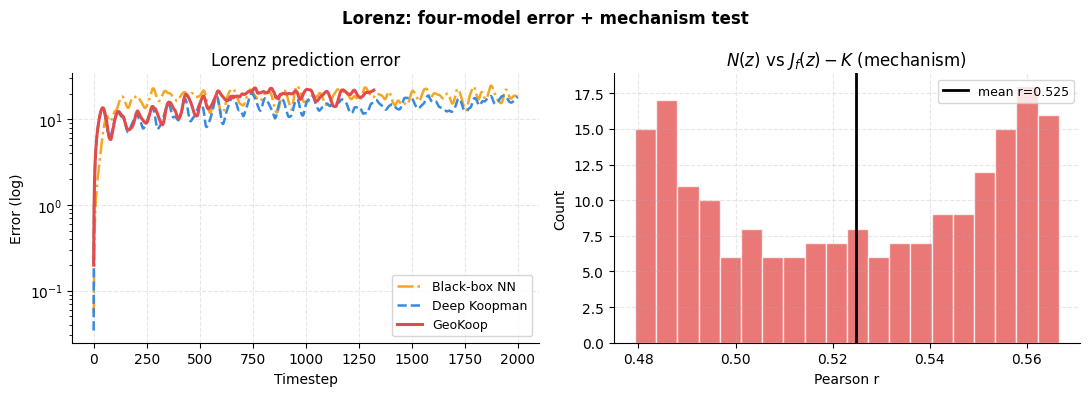

Saved lorenz_results.png


In [22]:
# Lorenz — generate data, train all four models, mechanism test
from scipy.integrate import solve_ivp

# ── Generate Lorenz data ────────────────────────────────────────
LZ_SIGMA  = 10.0
LZ_RHO    = 28.0
LZ_BETA   = 8.0/3.0
LZ_DT     = 0.01
LZ_T      = 2000
LZ_BURN   = 1000
LZ_LATENT = 6

def lorenz_rhs(t, y):
    x, y_, z = y
    return [LZ_SIGMA*(y_-x), x*(LZ_RHO-z)-y_, x*y_-LZ_BETA*z]

np.random.seed(1)
lz_trajs = []
for _ in range(50):
    x0  = np.random.randn(3)*5
    sol = solve_ivp(lorenz_rhs, [0,(LZ_T+LZ_BURN)*LZ_DT], x0,
                    t_eval=np.arange(LZ_T+LZ_BURN)*LZ_DT,
                    method='RK45', rtol=1e-8, atol=1e-10)
    lz_trajs.append(sol.y.T[LZ_BURN:])  # (LZ_T, 3)

lz_data  = np.stack(lz_trajs)   # (50, LZ_T, 3)
lz_mu_   = lz_data[:, :1000].mean(axis=(0,1))
lz_sig_  = lz_data[:, :1000].std(axis=(0,1)) + 1e-8
lz_n     = (lz_data - lz_mu_) / lz_sig_

lz_xt    = torch.tensor(lz_n[:, :-1].reshape(-1,3), dtype=torch.float32)
lz_xtp1  = torch.tensor(lz_n[:, 1:].reshape(-1,3),  dtype=torch.float32)
print(f"Lorenz data: {lz_data.shape}  train pairs: {lz_xt.shape}")

# ── Lorenz Koopman model ────────────────────────────────────────
class KoopmanLorenz(nn.Module):
    def __init__(self, d=LZ_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d,d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d,64), nn.Tanh(),
                nn.Linear(64,64), nn.Tanh(),
                nn.Linear(64, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)
    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_lorenz(ae, koop_or_bb, label, use_geo=True, is_bb=False,
                 epochs_p1=500, epochs_p2=2000, lr=1e-3,
                 rollout_steps=15):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    xt_d, xtp1_d = lz_xt.to(device), lz_xtp1.to(device)
    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        loss_rec = ((xt_d - ae.decode(z_t))**2).mean()
        z_pred   = koop_or_bb(z_t)
        loss_dyn = ((z_tp1 - z_pred)**2).mean()
        if epoch >= epochs_p1 and not is_bb:
            zr = z_t.clone()
            for _ in range(rollout_steps): zr = koop_or_bb(zr)
            loss_roll = ((z_tp1 - zr)**2).mean()
        else:
            loss_roll = torch.tensor(0., device=device)
        eig_loss = torch.tensor(0., device=device)
        if not is_bb:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01*((eigs.abs()-1)**2).mean()
        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 500 == 0:
            print(f"{label} ep={epoch:4d} | "
                  f"rec={loss_rec.item():.5f}  dyn={loss_dyn.item():.5f}")

# ── Train all four Lorenz models ────────────────────────────────
lz_ae_bb   = AE(3, LZ_LATENT).to(device)
lz_ae_base = AE(3, LZ_LATENT).to(device)
lz_ae_geo  = AE(3, LZ_LATENT).to(device)
lz_bb      = BlackBoxNN(LZ_LATENT, hidden=64).to(device)
lz_base    = KoopmanLorenz(LZ_LATENT, use_geo=False).to(device)
lz_geo     = KoopmanLorenz(LZ_LATENT, use_geo=True).to(device)

print("Training Lorenz Black-box...")
train_lorenz(lz_ae_bb,   lz_bb,   "Lz-BB",   use_geo=False, is_bb=True)
print("Training Lorenz Deep Koopman...")
train_lorenz(lz_ae_base, lz_base, "Lz-Base", use_geo=False)
print("Training Lorenz GeoKoop...")
train_lorenz(lz_ae_geo,  lz_geo,  "Lz-Geo",  use_geo=True)

# ── Lorenz rollout errors ───────────────────────────────────────
@torch.no_grad()
def lorenz_rollout(ae, dyn, traj_np):
    ae.eval(); dyn.eval()
    z = ae.encode(torch.tensor(traj_np[0:1], dtype=torch.float32).to(device))
    preds = [ae.decode(z).cpu().numpy()]
    for _ in range(len(traj_np)-1):
        z = dyn(z)
        preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds) * lz_sig_ + lz_mu_

test_lz   = lz_data[40:]
err_lz_bb   = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_bb,   lz_bb,   (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)
err_lz_base = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_base, lz_base, (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)
err_lz_geo  = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_geo,  lz_geo,  (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)

print(f"\nLorenz mean error (steps 100-500):")
geo_lm = err_lz_geo[100:500].mean()
print(f"  Black-box:    {err_lz_bb[100:500].mean():.4f}  "
      f"vs GeoKoop: {err_lz_bb[100:500].mean()/geo_lm:.2f}x")
print(f"  Deep Koopman: {err_lz_base[100:500].mean():.4f}  "
      f"vs GeoKoop: {err_lz_base[100:500].mean()/geo_lm:.2f}x")
print(f"  GeoKoop:      {geo_lm:.4f}")

# ── Mechanism test ──────────────────────────────────────────────
lz_x_samples = lz_n[:40, :1000].reshape(-1,3)[:200]
K_lz_np      = lz_geo.K.detach().cpu().numpy()

mech_lorenz = run_mechanism_test(
    koop       = lz_geo,
    ae         = lz_ae_geo,
    K_np       = K_lz_np,
    latent_dim = LZ_LATENT,
    x_samples  = lz_x_samples,
    label      = f"Lorenz (d={LZ_LATENT})",
    n_samples  = 200,
)

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Lorenz: four-model error + mechanism test",
             fontsize=12, fontweight='bold')
ts = np.arange(LZ_T)
axes[0].semilogy(ts, err_lz_bb+1e-8,   color=COLORS['BlackBox'],
                 ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
axes[0].semilogy(ts, err_lz_base+1e-8, color=COLORS['Baseline'],
                 ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
axes[0].semilogy(ts, err_lz_geo+1e-8,  color=COLORS['GeoKoop'],
                 ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Error (log)')
axes[0].set_title('Lorenz prediction error'); axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

r_lz = mech_lorenz["correlations"]
axes[1].hist(r_lz, bins=20, color=COLORS['GeoKoop'], alpha=0.75, edgecolor='white')
axes[1].axvline(r_lz.mean(), color='k', lw=2,
                label=f'mean r={r_lz.mean():.3f}')
axes[1].set_xlabel('Pearson r'); axes[1].set_ylabel('Count')
axes[1].set_title(r'$N(z)$ vs $J_f(z)-K$ (mechanism)')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['lorenz_results.png',
              f'{OUTPUT_DIR}/lorenz_results.png',
              f'{FIG_DIR}/lorenz_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved lorenz_results.png")


---
## Van der Pol & Lorenz — 5 seeds (four-model rollout + mechanism)
Loops 5 seeds reusing the data, models, training, rollout, and mechanism test defined just above; reports mean ± std for §5.3 and Table 4 (resumable).

In [23]:
# ══════════════════════════════════════════════════════════════════════
# Van der Pol & Lorenz — 5-seed four-model rollout + mechanism (resumable)
# Produces mean ± std for §5.3 and Table 4, matching Table 3's rigor.
# Reuses the data, model classes, train/rollout fns, and mechanism test
# defined in the VdP and Lorenz cells above. Data is generated once (those
# cells already ran); only model init + training vary with the seed.
# ══════════════════════════════════════════════════════════════════════
import os, json, numpy as np, torch

N_SEEDS_ODE = 5

ODE_SYS = {
    'Van der Pol': dict(
        obs=2, latent=VDP_LATENT, bb_hidden=32, tag='VdP',
        Koop=KoopmanVdP, train=train_vdp, rollout=vdp_rollout,
        data=vdp_data, mu=vdp_mu_, sig=vdp_sig_, test=slice(70, None),
        win=slice(50, None),
        xs=vdp_n[:70, :VDP_TRAIN].reshape(-1, 2)[:200]),
    'Lorenz': dict(
        obs=3, latent=LZ_LATENT, bb_hidden=64, tag='Lz',
        Koop=KoopmanLorenz, train=train_lorenz, rollout=lorenz_rollout,
        data=lz_data, mu=lz_mu_, sig=lz_sig_, test=slice(40, None),
        win=slice(100, 500),
        xs=lz_n[:40, :1000].reshape(-1, 3)[:200]),
}

def _run_one(name, cfg, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    obs, lat, tag = cfg['obs'], cfg['latent'], cfg['tag']
    ae_bb, ae_base, ae_geo = (AE(obs, lat).to(device) for _ in range(3))
    bb   = BlackBoxNN(lat, hidden=cfg['bb_hidden']).to(device)
    base = cfg['Koop'](lat, use_geo=False).to(device)
    geo  = cfg['Koop'](lat, use_geo=True).to(device)
    tr = cfg['train']
    tr(ae_bb,   bb,   f"{tag}-BB-s{seed}",   use_geo=False, is_bb=True)
    tr(ae_base, base, f"{tag}-Base-s{seed}", use_geo=False)
    tr(ae_geo,  geo,  f"{tag}-Geo-s{seed}",  use_geo=True)
    mu, sig, rf, w = cfg['mu'], cfg['sig'], cfg['rollout'], cfg['win']
    test = cfg['data'][cfg['test']]
    def werr(ae, dyn):
        e = np.mean([np.linalg.norm(rf(ae, dyn, (t - mu) / sig) - t, axis=1)
                     for t in test], axis=0)
        v = float(e[w].mean())
        return v if np.isfinite(v) else float('nan')
    res = dict(bb=werr(ae_bb, bb), base=werr(ae_base, base), geo=werr(ae_geo, geo))
    mech = run_mechanism_test(koop=geo, ae=ae_geo,
                              K_np=geo.K.detach().cpu().numpy(),
                              latent_dim=lat, x_samples=cfg['xs'],
                              label=f"{name} s{seed}", n_samples=200)
    res['r'] = float(np.mean(mech['correlations']))
    return res

CKPT_ODE = f"{OUTPUT_DIR}/vdp_lorenz_5seed_checkpoint.json"
ckpt = json.load(open(CKPT_ODE)) if os.path.exists(CKPT_ODE) else {}

for name, cfg in ODE_SYS.items():
    ckpt.setdefault(name, {})
    for seed in range(N_SEEDS_ODE):
        if str(seed) in ckpt[name]:
            print(f"{name} s{seed}: already done — skip"); continue
        print(f"\n{'='*54}\n{name} — seed {seed}\n{'='*54}")
        ckpt[name][str(seed)] = _run_one(name, cfg, seed)
        json.dump(ckpt, open(CKPT_ODE, 'w'))

# ── aggregate + print ─────────────────────────────────────────────────
def ms(v):
    v = np.array(v, float); v = v[np.isfinite(v)]
    if len(v) == 0: return float('nan'), float('nan')
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0)

print("\n" + "=" * 72)
print(f"VAN DER POL & LORENZ — {N_SEEDS_ODE} seeds (mean ± std)")
print("=" * 72)
for name, cfg in ODE_SYS.items():
    seeds = ckpt[name]
    bbv  = [seeds[s]['bb']   for s in seeds]
    basv = [seeds[s]['base'] for s in seeds]
    geov = [seeds[s]['geo']  for s in seeds]
    rv   = [seeds[s]['r']    for s in seeds]
    gm, gs = ms(geov); bm, bsd = ms(basv); xm, xsd = ms(bbv); rm, rsd = ms(rv)
    w = cfg['win']; wend = w.stop if w.stop is not None else 'end'
    print(f"\n{name}  (rollout error, window steps {w.start}-{wend}; {len(seeds)} seeds)")
    print(f"   Black-box   : {xm:8.3f} ± {xsd:.3f}   (vs GeoKoop {xm/gm:.2f}x)")
    print(f"   Deep Koopman: {bm:8.3f} ± {bsd:.3f}   (vs GeoKoop {bm/gm:.2f}x)")
    print(f"   GeoKoop     : {gm:8.3f} ± {gs:.3f}")
    print(f"   Mechanism r : {rm:.4f} ± {rsd:.4f}")
print("\n" + "=" * 72)
print("→ rollout means (GeoKoop/Deep/BB) go into §5.3;")
print("→ mechanism r (mean±std) goes into Table 4 for VdP and Lorenz.")


Van der Pol s0: already done — skip
Van der Pol s1: already done — skip
Van der Pol s2: already done — skip
Van der Pol s3: already done — skip
Van der Pol s4: already done — skip
Lorenz s0: already done — skip
Lorenz s1: already done — skip
Lorenz s2: already done — skip
Lorenz s3: already done — skip
Lorenz s4: already done — skip

VAN DER POL & LORENZ — 5 seeds (mean ± std)

Van der Pol  (rollout error, window steps 50-end; 5 seeds)
   Black-box   :    2.803 ± 0.247   (vs GeoKoop 0.97x)
   Deep Koopman:    2.426 ± 0.029   (vs GeoKoop 0.84x)
   GeoKoop     :    2.879 ± 0.565
   Mechanism r : 0.9129 ± 0.1131

Lorenz  (rollout error, window steps 100-500; 5 seeds)
   Black-box   :   18.435 ± 1.053   (vs GeoKoop 1.45x)
   Deep Koopman:   11.068 ± 0.465   (vs GeoKoop 0.87x)
   GeoKoop     :   12.700 ± 2.051
   Mechanism r : 0.6050 ± 0.2337

→ rollout means (GeoKoop/Deep/BB) go into §5.3;
→ mechanism r (mean±std) goes into Table 4 for VdP and Lorenz.


---
## Experiment 4 — Kuramoto-Sivashinsky PDE
Chaotic spatiotemporal PDE: u_t + u*u_x + u_xx + u_xxxx = 0.
Standard Koopman benchmark with richer attractor geometry than cylinder.
Domain: [0, 32π], periodic BC, N=64 grid points, dt=0.25.


Generating Kuramoto-Sivashinsky data...
KS data: (2501, 64), latent_dim=8
Train: 2000 steps, Test: 500 steps
Training KS Black-box...
KS-BB epoch 0: rec=1.00580  dyn=0.03225  roll=0.00000
KS-BB epoch 500: rec=0.06351  dyn=0.00364  roll=0.00000
KS-BB epoch 1000: rec=0.01485  dyn=0.00105  roll=0.00000
KS-BB epoch 1500: rec=0.00804  dyn=0.00051  roll=0.00000
KS-BB epoch 2000: rec=0.00541  dyn=0.00031  roll=0.00000
Training KS Deep Koopman...
KS-Base epoch 0: rec=1.00962  dyn=0.00014  roll=0.00000
KS-Base epoch 500: rec=0.04903  dyn=0.00642  roll=0.20437
KS-Base epoch 1000: rec=0.01449  dyn=0.00277  roll=0.00256
KS-Base epoch 1500: rec=0.00826  dyn=0.00181  roll=0.00167
KS-Base epoch 2000: rec=0.00575  dyn=0.00136  roll=0.00125
Training KS GeoKoop...
KS-Geo epoch 0: rec=1.00008  dyn=0.00013  roll=0.00000
KS-Geo epoch 500: rec=0.04287  dyn=0.00026  roll=3.99285
KS-Geo epoch 1000: rec=0.04768  dyn=0.00508  roll=0.03143
KS-Geo epoch 1500: rec=0.02600  dyn=0.00227  roll=0.01365
KS-Geo epoch 20

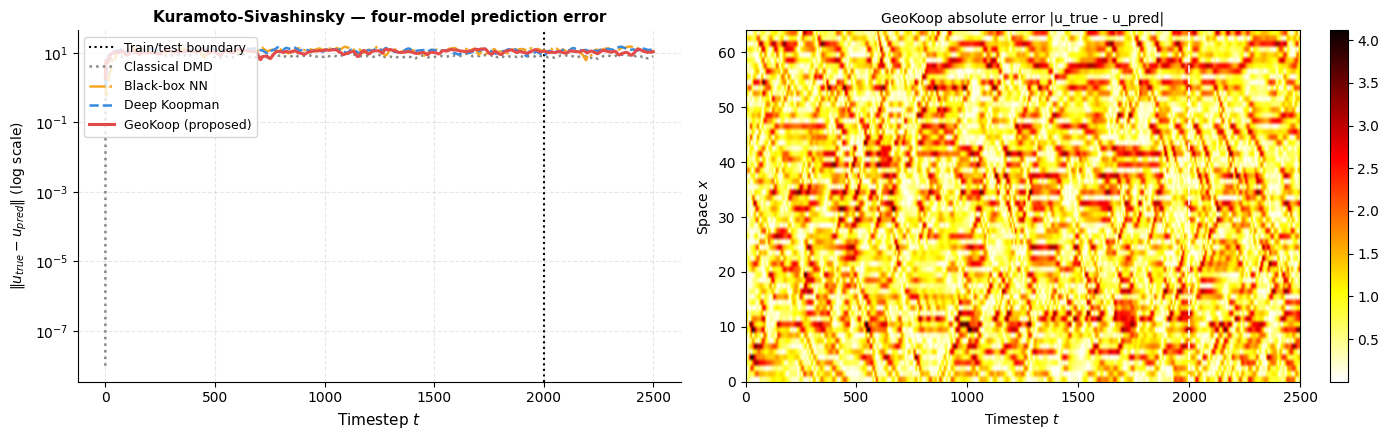


Kuramoto-Sivashinsky mean error (second half of training window):
  DMD:          8.0749
  Black-box NN: 11.7865   vs GeoKoop: 1.08x
  Deep Koopman: 11.3292   vs GeoKoop: 1.04x
  GeoKoop:      10.8912


In [24]:
# Kuramoto-Sivashinsky — generate data and run four-model comparison
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

# ── KS data generation ─────────────────────────────────────────
def ks_etdrk4(u0, L, dt, n_steps):
    """
    ETDRK4 integrator for Kuramoto-Sivashinsky:
      u_t + u*u_x + u_xx + u_xxxx = 0
    Spectral method on periodic domain [0, L].
    """
    N    = len(u0)
    k    = np.fft.rfftfreq(N, d=L/(2*np.pi*N))  # wavenumbers
    Lin  = k**2 - k**4                           # linear operator
    E    = np.exp(dt * Lin)
    E2   = np.exp(dt * Lin / 2)

    # ETDRK4 coefficients (Cox-Matthews)
    M    = 16
    r    = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)
    LR   = dt * Lin[:, None] + r[None, :]
    Q    = dt * np.real(np.mean((np.exp(LR/2)-1)/LR, axis=1))
    f1   = dt * np.real(np.mean((-4 - LR + np.exp(LR)*(4 - 3*LR + LR**2))/LR**3, axis=1))
    f2   = dt * np.real(np.mean((2  + LR + np.exp(LR)*(-2 + LR))/LR**3, axis=1))
    f3   = f1

    def NL(u_hat):
        u = np.fft.irfft(u_hat, N)
        return -0.5j * k * np.fft.rfft(u**2, N)

    traj = [u0.copy()]
    v    = np.fft.rfft(u0, N)
    for _ in range(n_steps):
        Nv   = NL(v)
        a    = E2*v + Q*Nv
        Na   = NL(a)
        b    = E2*v + Q*Na
        Nb   = NL(b)
        c    = E2*a + Q*(2*Nb - Nv)
        Nc   = NL(c)
        v    = E*v + Nv*f1 + 2*(Na+Nb)*f2 + Nc*f3
        traj.append(np.fft.irfft(v, N))
    return np.array(traj)  # (n_steps+1, N)

# Generate KS dataset
print("Generating Kuramoto-Sivashinsky data...")
KS_N    = 64       # spatial grid points
KS_L    = 32*np.pi # domain length
KS_DT   = 0.25    # time step
KS_BURN = 1000    # burn-in steps (discard transient)
KS_TRAIN= 2000    # training steps
KS_TEST = 500     # test steps

np.random.seed(42)
u0   = np.cos(np.linspace(0, 2*np.pi, KS_N, endpoint=False)) +        0.1*np.random.randn(KS_N)
full = ks_etdrk4(u0, KS_L, KS_DT, KS_BURN + KS_TRAIN + KS_TEST)
data = full[KS_BURN:]   # (KS_TRAIN + KS_TEST + 1, KS_N)

# Normalise
ks_mu  = data[:KS_TRAIN].mean()
ks_std = data[:KS_TRAIN].std()
data_n = (data - ks_mu) / ks_std

# Build trajectory pairs
KS_LATENT = 8
ks_xt  = torch.tensor(data_n[:-1], dtype=torch.float32)  # (T, N)
ks_xtp1= torch.tensor(data_n[1:],  dtype=torch.float32)

print(f"KS data: {data_n.shape}, latent_dim={KS_LATENT}")
print(f"Train: {KS_TRAIN} steps, Test: {KS_TEST} steps")

# ── KS Koopman model ───────────────────────────────────────────
class KoopmanKS(nn.Module):
    def __init__(self, d=KS_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d, 64), nn.Tanh(),
                nn.Linear(64, 64), nn.Tanh(),
                nn.Linear(64, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_ks(ae, koop_or_bb, label, use_geo=True, is_bb=False,
             epochs_p1=500, epochs_p2=2000, lam_geo=0.0,
             rollout_steps=20, lr=1e-3):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    xt_d   = ks_xt.to(device)
    xtp1_d = ks_xtp1.to(device)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        x_rec = ae.decode(z_t)

        loss_rec = ((xt_d - x_rec)**2).mean()
        if is_bb:
            z_pred    = koop_or_bb(z_t)
            loss_dyn  = ((z_tp1 - z_pred)**2).mean()
            loss_roll = torch.tensor(0., device=device)
        else:
            z_pred   = koop_or_bb(z_t)
            loss_dyn = ((z_tp1 - z_pred)**2).mean()
            if epoch >= epochs_p1:
                zr = z_t.clone()
                roll_losses = []
                for _ in range(rollout_steps):
                    zr = koop_or_bb(zr)
                roll_losses.append(((z_tp1 - zr)**2).mean())
                loss_roll = torch.stack(roll_losses).mean()
            else:
                loss_roll = torch.tensor(0., device=device)

        eig_loss = torch.tensor(0., device=device)
        if not is_bb and not use_geo is False:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01 * ((eigs.abs() - 1)**2).mean()

        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()

        if epoch % 500 == 0:
            print(f"{label} epoch {epoch}: rec={loss_rec.item():.5f}  "
                  f"dyn={loss_dyn.item():.5f}  roll={loss_roll.item():.5f}")

# ── Train all four KS models ───────────────────────────────────
ks_ae_dmd  = AE(KS_N, KS_LATENT).to(device)   # dummy AE for DMD
ks_ae_bb   = AE(KS_N, KS_LATENT).to(device)
ks_ae_base = AE(KS_N, KS_LATENT).to(device)
ks_ae_geo  = AE(KS_N, KS_LATENT).to(device)
ks_bb      = BlackBoxNN(KS_LATENT, hidden=64).to(device)
ks_base    = KoopmanKS(KS_LATENT, use_geo=False).to(device)
ks_geo     = KoopmanKS(KS_LATENT, use_geo=True).to(device)

print("Training KS Black-box...")
train_ks(ks_ae_bb,   ks_bb,   "KS-BB",   use_geo=False, is_bb=True)
print("Training KS Deep Koopman...")
train_ks(ks_ae_base, ks_base, "KS-Base", use_geo=False)
print("Training KS GeoKoop...")
train_ks(ks_ae_geo,  ks_geo,  "KS-Geo",  use_geo=True)

# ── DMD on KS ──────────────────────────────────────────────────
X_ks_n = data_n.T   # (KS_N, T)
X_ks   = X_ks_n[:, :KS_TRAIN]
Xp_ks  = X_ks_n[:, 1:KS_TRAIN+1]
U, S, Vt = np.linalg.svd(X_ks, full_matrices=False)
r_ks   = min(KS_LATENT, len(S))
Ur, Sr, Vtr = U[:, :r_ks], S[:r_ks], Vt[:r_ks, :]
A_dmd_ks = Xp_ks @ Vtr.T @ np.diag(1/Sr) @ Ur.T

# KS rollout
def ks_rollout_ae(ae, dyn, n_steps):
    ae.eval(); dyn.eval()
    with torch.no_grad():
        z = ae.encode(ks_xt[0:1].to(device))
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(n_steps - 1):
            z = dyn(z)
            preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds)   # (n_steps, KS_N)

n_eval       = KS_TRAIN + KS_TEST
X_ks_dmd     = np.zeros((n_eval, KS_N))
X_ks_dmd[0]  = data_n[0]
for k in range(1, n_eval):
    X_ks_dmd[k] = A_dmd_ks @ X_ks_dmd[k-1]

X_ks_bb   = ks_rollout_ae(ks_ae_bb,   ks_bb,   n_eval)
X_ks_base = ks_rollout_ae(ks_ae_base, ks_base, n_eval)
X_ks_geo  = ks_rollout_ae(ks_ae_geo,  ks_geo,  n_eval)

truth = data_n[:n_eval]
err_ks_dmd  = np.linalg.norm(truth - X_ks_dmd,  axis=1)
err_ks_bb   = np.linalg.norm(truth - X_ks_bb,   axis=1)
err_ks_base = np.linalg.norm(truth - X_ks_base, axis=1)
err_ks_geo  = np.linalg.norm(truth - X_ks_geo,  axis=1)

# ── KS figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ts_ks = np.arange(n_eval)

ax = axes[0]
ax.axvline(KS_TRAIN, color='k', ls=':', lw=1.5, label='Train/test boundary')
ax.semilogy(ts_ks, err_ks_dmd  + 1e-8, color=COLORS['DMD'],
            ls=STYLES['DMD'],      lw=1.8, label='Classical DMD')
ax.semilogy(ts_ks, err_ks_bb   + 1e-8, color=COLORS['BlackBox'],
            ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
ax.semilogy(ts_ks, err_ks_base + 1e-8, color=COLORS['Baseline'],
            ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
ax.semilogy(ts_ks, err_ks_geo  + 1e-8, color=COLORS['GeoKoop'],
            ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop (proposed)')
ax.set_xlabel('Timestep $t$', fontsize=11)
ax.set_ylabel(r'$\|u_{true} - u_{pred}\|$ (log scale)', fontsize=10)
ax.set_title('Kuramoto-Sivashinsky — four-model prediction error',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Spacetime plot of GeoKoop prediction
ax2 = axes[1]
diff = np.abs(truth - X_ks_geo).T
im = ax2.imshow(diff, aspect='auto', cmap='hot_r', origin='lower',
                extent=[0, n_eval, 0, KS_N])
ax2.axvline(KS_TRAIN, color='white', ls='--', lw=1.5, alpha=0.8)
plt.colorbar(im, ax=ax2, fraction=0.03)
ax2.set_xlabel('Timestep $t$', fontsize=10)
ax2.set_ylabel('Space $x$', fontsize=10)
ax2.set_title('GeoKoop absolute error |u_true - u_pred|', fontsize=10)

plt.tight_layout()
for fname in ['ks_results.png',
              f'{OUTPUT_DIR}/ks_results.png',
              f'{FIG_DIR}/ks_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()

# ── KS summary ─────────────────────────────────────────────────
eval_start = KS_TRAIN // 2
print()
print("Kuramoto-Sivashinsky mean error (second half of training window):")
geo_m = err_ks_geo[eval_start:KS_TRAIN].mean()
print(f"  DMD:          {err_ks_dmd[eval_start:KS_TRAIN].mean():.4f}")
print(f"  Black-box NN: {err_ks_bb[eval_start:KS_TRAIN].mean():.4f}   "
      f"vs GeoKoop: {err_ks_bb[eval_start:KS_TRAIN].mean()/geo_m:.2f}x")
print(f"  Deep Koopman: {err_ks_base[eval_start:KS_TRAIN].mean():.4f}   "
      f"vs GeoKoop: {err_ks_base[eval_start:KS_TRAIN].mean()/geo_m:.2f}x")
print(f"  GeoKoop:      {geo_m:.4f}")


In [25]:
# ════════════════════════════════════════════════════════════════
# Kuramoto-Sivashinsky — 5-SEED rollout for Table 3 (resumable)
# Metric: mean error over t = KS_TRAIN//2 .. KS_TRAIN (second-half
# window) — identical to the single-seed KS cell above. DMD is
# deterministic (seed-independent); BB / Deep Koopman / GeoKoop are
# retrained per seed. Reuses KoopmanKS / train_ks / ks_rollout_ae / A_dmd_ks.
# ════════════════════════════════════════════════════════════════
import os, json
N_SEEDS    = 5
eval_start = KS_TRAIN // 2
n_eval     = KS_TRAIN + KS_TEST
truth_ks   = data_n[:n_eval]

# DMD (deterministic) — roll once
X_ks_dmd = np.zeros((n_eval, KS_N)); X_ks_dmd[0] = data_n[0]
for k in range(1, n_eval):
    X_ks_dmd[k] = A_dmd_ks @ X_ks_dmd[k-1]
ks_dmd_err = float(np.linalg.norm(truth_ks - X_ks_dmd, axis=1)[eval_start:KS_TRAIN].mean())

def _ks_err(ae, dyn):
    X = ks_rollout_ae(ae, dyn, n_eval)
    return float(np.linalg.norm(truth_ks - X, axis=1)[eval_start:KS_TRAIN].mean())

CKPT_KS = f"{OUTPUT_DIR}/table3_ks_checkpoint.json"
ks_ckpt = json.load(open(CKPT_KS)) if os.path.exists(CKPT_KS) else {}

for seed in range(N_SEEDS):
    if str(seed) in ks_ckpt:
        print(f'KS s{seed}: already done — skipping'); continue
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    try:
        ae_b = AE(KS_N, KS_LATENT).to(device); bb_s = BlackBoxNN(KS_LATENT, hidden=64).to(device)
        train_ks(ae_b, bb_s, f'KS-BB-s{seed}',   use_geo=False, is_bb=True)
        ae_s = AE(KS_N, KS_LATENT).to(device); kp_s = KoopmanKS(KS_LATENT, use_geo=False).to(device)
        train_ks(ae_s, kp_s, f'KS-Base-s{seed}', use_geo=False)
        ae_g = AE(KS_N, KS_LATENT).to(device); kg_s = KoopmanKS(KS_LATENT, use_geo=True).to(device)
        train_ks(ae_g, kg_s, f'KS-Geo-s{seed}',  use_geo=True)
        rec = {'dmd': ks_dmd_err, 'bb': _ks_err(ae_b, bb_s),
               'base': _ks_err(ae_s, kp_s), 'geo': _ks_err(ae_g, kg_s)}
    except Exception as e:
        print(f'   seed {seed} FAILED: {repr(e)[:110]}')
        rec = {'dmd': ks_dmd_err, 'bb': float('nan'), 'base': float('nan'), 'geo': float('nan')}
    ks_ckpt[str(seed)] = rec
    json.dump(ks_ckpt, open(CKPT_KS, 'w'), indent=2)
    print(f'KS s{seed}: DMD={rec["dmd"]:.3f}  BB={rec["bb"]:.3f}  '
          f'Base={rec["base"]:.3f}  Geo={rec["geo"]:.3f}   [checkpoint saved]')

res_ks = {k: [ks_ckpt[str(s)][k] for s in range(N_SEEDS) if str(s) in ks_ckpt]
          for k in ['dmd', 'bb', 'base', 'geo']}

def _ksms(v):
    v = np.array(v, float); v = v[np.isfinite(v)]
    return (v.mean(), v.std(ddof=1)) if len(v) > 1 else ((v.mean(), 0.0) if len(v) else (float('nan'), 0.0))

n_fin = len([x for x in res_ks['geo'] if np.isfinite(x)])
if n_fin == N_SEEDS:
    gm, gs = _ksms(res_ks['geo']); bm, _ = _ksms(res_ks['base']); xm, _ = _ksms(res_ks['bb'])
    print(f"\nKuramoto-Sivashinsky 5-seed: Geo={gm:.3f}±{gs:.3f}  DMD={ks_dmd_err:.3f}  "
          f"vs DK={bm/gm:.2f}x  vs BB={xm/gm:.2f}x\n")
else:
    print(f"\nKS: {n_fin}/{N_SEEDS} finite seeds — re-run to continue / inspect divergence.\n")


KS s0: already done — skipping
KS s1: already done — skipping
KS s2: already done — skipping
KS s3: already done — skipping
KS s4: already done — skipping

Kuramoto-Sivashinsky 5-seed: Geo=11.953±3.261  DMD=8.075  vs DK=0.99x  vs BB=1.01x



---
## Table 3 — Four-Model Comparison (placed after Experiment 4)
Consolidated 5-seed mean ± std with vsDK / vsBB ratio columns. Pulls `res_p`, `res_f`, `res_c`, `res_ks` (+ VdP/Lorenz checkpoint).

In [26]:
# ════════════════════════════════════════════════════════════════════════
# TABLE 3 — Four-model comparison (5 seeds, mean ± std)
# Placed right after Experiment 4 (KS) so every row's results are in scope.
# Core rows (paper Table 3): Pendulum, FluidFlowBox, Cylinder.
# Extended rows shown where available: Van der Pol, Lorenz, KS.
# Reloads res_* from checkpoints if a session restart cleared memory.
# ════════════════════════════════════════════════════════════════════════
import os, json, numpy as np

def _reload(path, keys=('dmd', 'bb', 'base', 'geo')):
    if not os.path.exists(path): return None
    d = json.load(open(path)); ss = sorted(d, key=lambda x: int(x))
    return {k: [d[s][k] for s in ss if k in d[s]] for k in keys}

res_p_use  = globals().get('res_p')
res_f_use  = globals().get('res_f')  or _reload(f"{OUTPUT_DIR}/table3_fluid_checkpoint.json")
res_c_use  = globals().get('res_c')  or _reload(f"{OUTPUT_DIR}/table3_cylinder_checkpoint.json")
res_ks_use = globals().get('res_ks')

ode = {}
_ode_path = f"{OUTPUT_DIR}/vdp_lorenz_5seed_checkpoint.json"
if os.path.exists(_ode_path): ode = json.load(open(_ode_path))
def _ode_row(name):
    d = ode.get(name, {})
    if not d: return None
    return {k: [d[s][k] for s in sorted(d) if k in d[s]] for k in ['bb', 'base', 'geo']}

def _ms(res, key):
    if not res or key not in res: return None
    v = np.array([x for x in res[key] if np.isfinite(x)], float)
    return None if v.size == 0 else (v.mean(), v.std(ddof=1) if v.size > 1 else 0.0)

def _cell(res, key):
    ms = _ms(res, key)
    return f"{'—':^14}" if ms is None else f"{ms[0]:8.3f}±{ms[1]:.3f}"

def _ratio(res, num):
    a, gg = _ms(res, num), _ms(res, 'geo')
    return f"{'—':^6}" if (a is None or gg is None or gg[0] == 0) else f"{a[0]/gg[0]:5.1f}x"

rows = [
    ('Pendulum (@49)',              res_p_use,  True),
    ('FluidFlowBox (@49)',          res_f_use,  True),
    ('Cylinder (t=100-150)',        res_c_use,  True),
    ('Van der Pol (window)',        _ode_row('Van der Pol'), False),
    ('Lorenz (window)',             _ode_row('Lorenz'),      False),
    ('Kuramoto-Sivash. (2nd half)', res_ks_use, True),
]

W = 104
print('=' * W)
print('TABLE 3 — FOUR-MODEL COMPARISON  (5 seeds, mean ± std)')
print('=' * W)
print(f"  {'System':<28} {'DMD':>9} {'Black-box':>15} {'Deep K.':>15} "
      f"{'GeoKoop':>15} {'vsDK':>6} {'vsBB':>6}")
print('-' * W)
for label, res, has_dmd in rows:
    dmd = _ms(res, 'dmd')
    dmd_s = f"{dmd[0]:9.3f}" if (has_dmd and dmd) else f"{'—':^9}"
    print(f"  {label:<28} {dmd_s} {_cell(res,'bb'):>15} {_cell(res,'base'):>15} "
          f"{_cell(res,'geo'):>15} {_ratio(res,'base'):>6} {_ratio(res,'bb'):>6}")
print('=' * W)
print("vsDK = Deep Koopman / GeoKoop,  vsBB = Black-box / GeoKoop   (>1 => GeoKoop wins)")
print("DMD undefined for Van der Pol / Lorenz. Metric differs per row (see labels);")
print("errors are comparable across models within a row, not across rows.")

table3_results = {'pendulum': res_p_use, 'fluidflowbox': res_f_use,
                  'cylinder': res_c_use, 'ks': res_ks_use}
_missing = [lbl for lbl, res, _ in rows if res is None]
if _missing:
    print("\n[!] No results yet for: " + ", ".join(_missing)
          + " — run that experiment's 5-seed cell first.")


TABLE 3 — FOUR-MODEL COMPARISON  (5 seeds, mean ± std)
  System                             DMD       Black-box         Deep K.         GeoKoop   vsDK   vsBB
--------------------------------------------------------------------------------------------------------
  Pendulum (@49)                   0.869     0.070±0.008     0.214±0.028     0.017±0.006  12.3x   4.0x
  FluidFlowBox (@49)               1.344     1.283±0.034     1.334±0.004     1.314±0.009   1.0x   1.0x
  Cylinder (t=100-150)           155.770     0.977±0.121  155.795±10.090     0.760±0.057 205.0x   1.3x
  Van der Pol (window)             —         2.803±0.247     2.426±0.029     2.879±0.565   0.8x   1.0x
  Lorenz (window)                  —        18.435±1.053    11.068±0.465    12.700±2.051   0.9x   1.5x
  Kuramoto-Sivash. (2nd half)      8.075    12.041±0.368    11.790±0.609    11.953±3.261   1.0x   1.0x
vsDK = Deep Koopman / GeoKoop,  vsBB = Black-box / GeoKoop   (>1 => GeoKoop wins)
DMD undefined for Van der Pol / Loren

---
## Mechanism Test — Kuramoto-Sivashinsky (d=8)
Test N(z) ≈ J_f(z) - K on the KS PDE system.



Mechanism test: N(z) ≈ J_f(z)-K  [Kuramoto-Sivashinsky (d=8)]
  Samples : 150  (latent d=8)
  ||N(z)||_F        mean=0.5719  std=0.0376
  ||J_f-K||_F       mean=0.6207  std=0.0532
  ||N-(J_f-K)||_F   mean=0.1897  std=0.0521
  Relative error    mean=0.3082  std=0.0945
  Pearson r         mean=0.9472  std=0.0376  n=150
  RESULT: STRONG


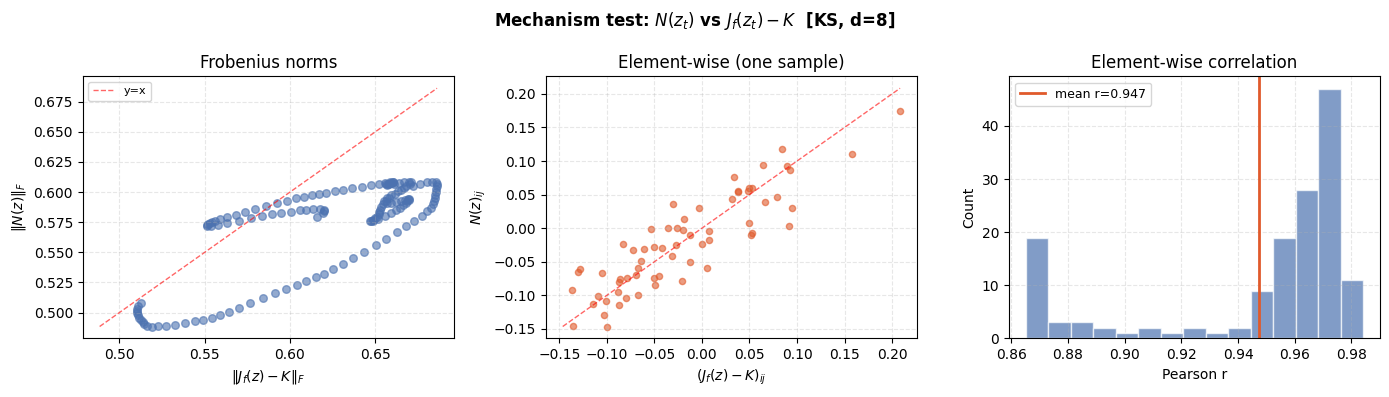

Saved ks_mechanism.png


In [27]:
# Mechanism test — Kuramoto-Sivashinsky (d=8)
KS_MECH_SAMPLES = 150

# Sample from KS training data (normalised)
ks_x_samples = data_n[:KS_MECH_SAMPLES]   # (N, KS_N=64)

K_ks_np = ks_geo.K.detach().cpu().numpy()

mech_ks = run_mechanism_test(
    koop       = ks_geo,
    ae         = ks_ae_geo,
    K_np       = K_ks_np,
    latent_dim = KS_LATENT,
    x_samples  = ks_x_samples,
    label      = f"Kuramoto-Sivashinsky (d={KS_LATENT})",
    n_samples  = KS_MECH_SAMPLES,
)

# ── Figure: KS mechanism ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$  "
             f"[KS, d={KS_LATENT}]",
             fontsize=12, fontweight='bold')

r_ks = mech_ks["correlations"]
axes[0].scatter(mech_ks["Jf_K_norms"], mech_ks["N_norms"],
                alpha=0.6, s=30, color='#4C72B0')
lims = [min(mech_ks["Jf_K_norms"].min(), mech_ks["N_norms"].min()),
        max(mech_ks["Jf_K_norms"].max(), mech_ks["N_norms"].max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$"); axes[0].set_ylabel(r"$\|N(z)\|_F$")
axes[0].set_title("Frobenius norms"); axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

z_s   = mech_ks["latent_states"][0]
_dev  = get_device(ks_geo)
dyn_k = make_latent_dynamics_fn(ks_geo)
z_t   = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = ks_geo.N_net(z_t).view(KS_LATENT, KS_LATENT).cpu().numpy()
Jf_s  = finite_diff_jacobian(dyn_k, z_s)
JfK_s = Jf_s - K_ks_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(), alpha=0.6, s=20, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$"); axes[1].set_ylabel(r"$N(z)_{ij}$")
axes[1].set_title("Element-wise (one sample)")
axes[1].grid(True, linestyle='--', alpha=0.3)

axes[2].hist(r_ks, bins=15, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[2].axvline(r_ks.mean(), color='#E05A2B', lw=2,
                label=f'mean r={r_ks.mean():.3f}')
axes[2].set_xlabel("Pearson r"); axes[2].set_ylabel("Count")
axes[2].set_title("Element-wise correlation"); axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['ks_mechanism.png',
              f'{OUTPUT_DIR}/ks_mechanism.png',
              f'{FIG_DIR}/ks_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved ks_mechanism.png")


---
## Stage 2 Ablation — Kuramoto-Sivashinsky (Section 6.3)
Matrix vs. vector structure ablation on KS with 5 seeds per condition.
Four conditions: deep, vec_wm (width-matched), vec_pm (param-matched), GeoKoop.


In [28]:
# ── KS Ablation: matrix vs vector structure, 5 seeds ─────────────────
# Requires: KS data (data_n, ks_xt, ks_xtp1) from Cell 30
# Requires: KoopmanKS, train_ks, AE, BlackBoxNN from earlier cells

N_SEEDS_KS = 5

# ── Parameter counts ──────────────────────────────────────────────────
# GeoKoop N_net: d->64->64->d*d
# d=KS_LATENT=8, so d*d=64
# N_net params: 8*64 + 64 + 64*64 + 64 + 64*64 + 64 = 512+64+4096+64+4096+64 = 8896
# vec_pm: match 8896 params with output d=8
# hidden h: h*8 + h + h*h + h + h*8 = 8h+h+h^2+h+8h = h^2+18h
# h^2+18h = 8896 → h ≈ 86
KS_GEO_PARAMS = KS_LATENT*64 + 64 + 64*64 + 64 + 64*KS_LATENT*KS_LATENT
KS_VEC_WM_H   = 64           # same hidden width as N_net
KS_VEC_PM_H   = 86           # parameter-matched hidden width

print(f"KS latent dim: {KS_LATENT}")
print(f"GeoKoop N_net params: {KS_GEO_PARAMS}")

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ── Vector residual model ──────────────────────────────────────────────
class VecResidualKS(nn.Module):
    """Kz + g(z) where g: R^d -> R^d (vector residual)."""
    def __init__(self, d=KS_LATENT, hidden=64):
        super().__init__()
        self.d = d
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        self.g = nn.Sequential(
            nn.Linear(d, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))
        nn.init.zeros_(self.g[-1].weight)
        nn.init.zeros_(self.g[-1].bias)

    def forward(self, z):
        return z @ self.K.T + self.g(z)

# ── Rollout helper ─────────────────────────────────────────────────────
def ks_rollout_err(ae, dyn, n_steps, truth):
    """Rollout from truth[0], return per-step error array."""
    ae.eval(); dyn.eval()
    with torch.no_grad():
        z = ae.encode(torch.tensor(truth[0:1], dtype=torch.float32).to(device))
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(n_steps - 1):
            z = dyn(z)
            preds.append(ae.decode(z).cpu().numpy())
    pred_arr = np.vstack(preds)
    return np.linalg.norm(truth - pred_arr, axis=1)

# ── 5-seed ablation ────────────────────────────────────────────────────
ablation_conditions = {
    "deep":    [],
    "vec_wm":  [],
    "vec_pm":  [],
    "geo":     [],
}
N_EVAL = KS_TRAIN  # evaluate over full training window

for seed in range(N_SEEDS_KS):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    print(f"\n{'='*50}")
    print(f"KS Ablation Seed {seed}")
    print(f"{'='*50}")

    # ── deep (no correction) ──────────────────────────────────────────
    ae_d   = AE(KS_N, KS_LATENT).to(device)
    koop_d = KoopmanKS(KS_LATENT, use_geo=False).to(device)
    train_ks(ae_d, koop_d, f"KS-deep-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_d = ks_rollout_err(ae_d, koop_d, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["deep"].append(err_d[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  deep:   err_late={ablation_conditions['deep'][-1]:.4f}")

    # ── vec_wm (width-matched vector residual) ────────────────────────
    ae_wm   = AE(KS_N, KS_LATENT).to(device)
    vec_wm  = VecResidualKS(KS_LATENT, hidden=KS_VEC_WM_H).to(device)
    train_ks(ae_wm, vec_wm, f"KS-vecwm-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_wm = ks_rollout_err(ae_wm, vec_wm, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["vec_wm"].append(err_wm[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  vec_wm: err_late={ablation_conditions['vec_wm'][-1]:.4f}  "
          f"params={count_params(vec_wm.g)}")

    # ── vec_pm (parameter-matched vector residual) ────────────────────
    ae_pm   = AE(KS_N, KS_LATENT).to(device)
    vec_pm  = VecResidualKS(KS_LATENT, hidden=KS_VEC_PM_H).to(device)
    train_ks(ae_pm, vec_pm, f"KS-vecpm-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_pm = ks_rollout_err(ae_pm, vec_pm, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["vec_pm"].append(err_pm[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  vec_pm: err_late={ablation_conditions['vec_pm'][-1]:.4f}  "
          f"params={count_params(vec_pm.g)}")

    # ── GeoKoop ───────────────────────────────────────────────────────
    ae_geo   = AE(KS_N, KS_LATENT).to(device)
    koop_geo = KoopmanKS(KS_LATENT, use_geo=True).to(device)
    train_ks(ae_geo, koop_geo, f"KS-geo-s{seed}",
             use_geo=True, rollout_steps=10, lr=5e-4)
    err_geo = ks_rollout_err(ae_geo, koop_geo, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["geo"].append(err_geo[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  geo:    err_late={ablation_conditions['geo'][-1]:.4f}  "
          f"params={count_params(koop_geo.N_net)}")

# ── Summary table ──────────────────────────────────────────────────────
print()
print("=" * 65)
print("KS ABLATION RESULTS (5 seeds, err_late = mean error t=1000-2000)")
print("=" * 65)
print(f"  {'Condition':<12} {'N-params':>10}  {'err_late':>20}  {'vs geo':>8}")
print("-" * 65)

geo_mean = np.mean(ablation_conditions["geo"])
for cond, h, params in [
    ("deep",   None, 0),
    ("vec_wm", KS_VEC_WM_H, None),
    ("vec_pm", KS_VEC_PM_H, None),
    ("geo",    None, KS_GEO_PARAMS),
]:
    vals = ablation_conditions[cond]
    m = np.mean(vals); s = np.std(vals, ddof=1)
    vs = m / geo_mean
    if cond == "vec_wm":
        npar = count_params(VecResidualKS(KS_LATENT, hidden=KS_VEC_WM_H).g)
    elif cond == "vec_pm":
        npar = count_params(VecResidualKS(KS_LATENT, hidden=KS_VEC_PM_H).g)
    else:
        npar = params
    print(f"  {cond:<12} {npar:>10}  {m:>8.3f}±{s:<8.3f}  {vs:>7.2f}x")
print("=" * 65)
print()
print("Copy these numbers into Table 6 (KS ablation) in the paper.")
print("If geo << vec_pm at equal params → Section 6.3 is confirmed.")
print("If geo ≈ vec_pm → KS does not show the matrix advantage.")


KS latent dim: 8
GeoKoop N_net params: 8832

KS Ablation Seed 0
KS-deep-s0 epoch 0: rec=0.99647  dyn=0.00010  roll=0.00000
KS-deep-s0 epoch 500: rec=0.17014  dyn=0.00847  roll=0.04955
KS-deep-s0 epoch 1000: rec=0.03909  dyn=0.00497  roll=0.00469
KS-deep-s0 epoch 1500: rec=0.01835  dyn=0.00318  roll=0.00301
KS-deep-s0 epoch 2000: rec=0.01140  dyn=0.00228  roll=0.00216
  deep:   err_late=11.9671
KS-vecwm-s0 epoch 0: rec=1.00322  dyn=0.00013  roll=0.00000
KS-vecwm-s0 epoch 500: rec=0.15928  dyn=0.00917  roll=0.05808
KS-vecwm-s0 epoch 1000: rec=0.03687  dyn=0.00489  roll=0.00464
KS-vecwm-s0 epoch 1500: rec=0.01747  dyn=0.00311  roll=0.00295
KS-vecwm-s0 epoch 2000: rec=0.01085  dyn=0.00224  roll=0.00212
  vec_wm: err_late=11.1703  params=5256
KS-vecpm-s0 epoch 0: rec=1.00147  dyn=0.00014  roll=0.00000
KS-vecpm-s0 epoch 500: rec=0.15206  dyn=0.00929  roll=0.05840
KS-vecpm-s0 epoch 1000: rec=0.03545  dyn=0.00487  roll=0.00462
KS-vecpm-s0 epoch 1500: rec=0.01694  dyn=0.00309  roll=0.00293
KS-v

---
## Stage 2 — Cylinder ablation: matrix vs vector structure
Regenerates the cylinder ablation table and `figure4_cylinder_ablation.png` with the current 5-seed setup (resumable).

Cyl-abl s0: already done — skipping
Cyl-abl s1: already done — skipping
Cyl-abl s2: already done — skipping
Cyl-abl s3: already done — skipping
Cyl-abl s4: already done — skipping

CYLINDER ABLATION  (5/5 seeds)   err_late = headline (t=100-150)
  Condition   N-params       err_train        err_late         err_ext
--------------------------------------------------------------------------
  deep               0   134.78±26.49   154.04±4.49    171.42±32.34
  vec_wm          6288     1.26±0.08      1.33±0.10      1.69±0.36 
  vec_pm         21928     0.81±0.03      0.86±0.05      2.40±2.16 
  GeoKoop        21888     0.72±0.08      0.79±0.08      0.85±0.28 
  vec_pm vs GeoKoop:  1x accuracy (err_late),  seed-std 0.05 vs 0.082
  -> if GeoKoop << vec_pm at equal params, the matrix advantage is confirmed.


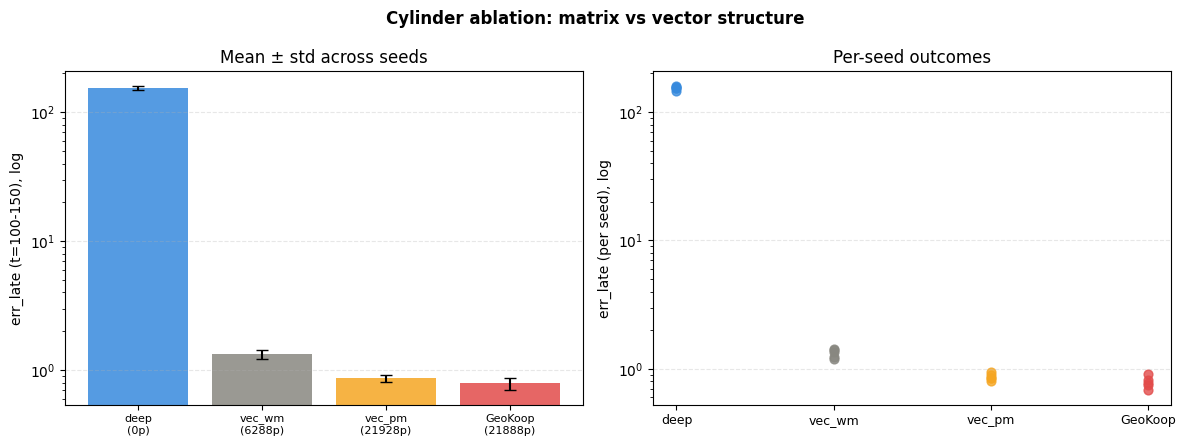


Saved figure4_cylinder_ablation.png
Copy the err_late column into the cylinder-ablation table in the paper.


In [29]:
# ══════════════════════════════════════════════════════════════════════
# Cylinder Ablation: matrix vs vector structure, 5 seeds (resumable)
# Regenerates the cylinder ablation table + figure4_cylinder_ablation.png
# Reuses: cyl_ae, cyl_koop, train_model, cyl_rollout, KoopmanCore, AE,
#         A_dmd_c_orig, cx_t, cx_tp1, vort_all, COLORS, OUTPUT_DIR, device
# ══════════════════════════════════════════════════════════════════════
import os, json, numpy as np, torch
import matplotlib.pyplot as plt

N_SEEDS_CYL = 5
d_cyl = C_LATENT  # 16

# Param counts (correction network only, matching the paper):
#   GeoKoop N_net: d->64->64->d*d = (16*64+64)+(64*64+64)+(64*256+256) = 21,888
#   vector g:      d->h->h->d, params = h^2 + 34h + 16
#       h=64  -> 6,288   (width-matched : vec_wm)
#       h=132 -> 21,928  (parameter-matched : vec_pm)
CYL_VEC_WM_H = 64
CYL_VEC_PM_H = 132

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Vector-residual model: z@K.T + g(z),  g: R^d -> R^d ────────────────
# g is named `N_net` so the existing train_model() optimiser (which adds
# koopman.N_net.parameters() only when use_geo=True) trains it on the SAME
# schedule and learning rate as GeoKoop. forward() replaces the matrix
# update K+N(z) with the vector update Kz + g(z).
class VecResidualCyl(nn.Module):
    def __init__(self, d, K_init, hidden):
        super().__init__()
        self.d = d; self.use_geo = True
        K_arr = np.array(K_init, dtype=np.float32)
        self.K = nn.Parameter(torch.tensor(K_arr[:d, :d], dtype=torch.float32))
        self.N_net = nn.Sequential(          # vector residual g (NOT a matrix)
            nn.Linear(d, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))
        nn.init.zeros_(self.N_net[-1].weight); nn.init.zeros_(self.N_net[-1].bias)
    def forward(self, z):
        return z @ self.K.T + self.N_net(z)
    def geo_loss(self, z):
        return torch.tensor(0.0, device=z.device)

def _cyl_err_windows(ae, dyn):
    """Full-space rollout error split into train / late / extrapolation windows."""
    pred = cyl_rollout(ae, dyn)                       # (n_space, T_total)
    err  = np.linalg.norm(vort_all - pred, axis=0)
    e_tr  = float(err[:100].mean())
    e_lat = float(err[100:150].mean()) if err.shape[0] > 100 else float('nan')
    e_ext = float(err[150:].mean())    if err.shape[0] > 150 else float('nan')
    return [e_tr, e_lat, e_ext]

# ── resumable checkpoint (survives Colab disconnects) ─────────────────
CKPT_ABL = f"{OUTPUT_DIR}/cylinder_ablation_checkpoint.json"
def _load_abl():
    return json.load(open(CKPT_ABL)) if os.path.exists(CKPT_ABL) else {}
def _save_abl(d):
    json.dump(d, open(CKPT_ABL, 'w'))
abl_ckpt = _load_abl()

EP1, EP2, RS = 500, 3000, 20   # identical schedule to the four-model cylinder run

for seed in range(N_SEEDS_CYL):
    if str(seed) in abl_ckpt:
        print(f"Cyl-abl s{seed}: already done — skipping"); continue
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    print(f"\n{'='*54}\nCylinder ablation — seed {seed}\n{'='*54}")
    rec = {}

    # deep (Deep Koopman, no correction)
    ae = cyl_ae(d_cyl); dyn = cyl_koop(d_cyl, geo=False)
    train_model(ae, dyn, cx_t, cx_tp1, use_geo=False, label=f'Cyl-abl-deep-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=RS)
    rec['deep'] = _cyl_err_windows(ae, dyn); rec['deep_np'] = 0

    # vec_wm (vector residual, width-matched)
    ae = cyl_ae(d_cyl)
    dyn = VecResidualCyl(d_cyl, A_dmd_c_orig, CYL_VEC_WM_H).to(device)
    train_model(ae, dyn, cx_t, cx_tp1, use_geo=True, label=f'Cyl-abl-vecwm-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=RS, lam_geo=0.0)
    rec['vec_wm'] = _cyl_err_windows(ae, dyn); rec['vec_wm_np'] = count_params(dyn.N_net)

    # vec_pm (vector residual, parameter-matched)
    ae = cyl_ae(d_cyl)
    dyn = VecResidualCyl(d_cyl, A_dmd_c_orig, CYL_VEC_PM_H).to(device)
    train_model(ae, dyn, cx_t, cx_tp1, use_geo=True, label=f'Cyl-abl-vecpm-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=RS, lam_geo=0.0)
    rec['vec_pm'] = _cyl_err_windows(ae, dyn); rec['vec_pm_np'] = count_params(dyn.N_net)

    # GeoKoop (matrix correction)
    ae = cyl_ae(d_cyl); dyn = cyl_koop(d_cyl, geo=True)
    train_model(ae, dyn, cx_t, cx_tp1, use_geo=True, label=f'Cyl-abl-geo-s{seed}',
                epochs_p1=EP1, epochs_p2=EP2, rollout_steps=RS, lam_geo=0.0)
    rec['geo'] = _cyl_err_windows(ae, dyn); rec['geo_np'] = count_params(dyn.N_net)

    abl_ckpt[str(seed)] = rec; _save_abl(abl_ckpt)
    print(f"  deep late={rec['deep'][1]:.3f} | vec_wm late={rec['vec_wm'][1]:.3f} "
          f"| vec_pm late={rec['vec_pm'][1]:.3f} | geo late={rec['geo'][1]:.3f}")

# ── aggregate over completed seeds ────────────────────────────────────
conds = ['deep', 'vec_wm', 'vec_pm', 'geo']
labelmap = {'deep': 'deep', 'vec_wm': 'vec_wm', 'vec_pm': 'vec_pm', 'geo': 'GeoKoop'}
done = sorted(int(s) for s in abl_ckpt)
agg = {c: {'train': [], 'late': [], 'ext': [], 'np': None} for c in conds}
for s in done:
    rec = abl_ckpt[str(s)]
    for c in conds:
        tr, la, ex = rec[c]
        agg[c]['train'].append(tr); agg[c]['late'].append(la); agg[c]['ext'].append(ex)
        agg[c]['np'] = rec[f'{c}_np']

def ms(v):
    v = np.array(v, float); v = v[~np.isnan(v)]
    if len(v) == 0: return float('nan'), float('nan')
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0)

print("\n" + "=" * 74)
print(f"CYLINDER ABLATION  ({len(done)}/{N_SEEDS_CYL} seeds)   err_late = headline (t=100-150)")
print("=" * 74)
print(f"  {'Condition':<10}{'N-params':>10}{'err_train':>16}{'err_late':>16}{'err_ext':>16}")
print("-" * 74)
for c in conds:
    tm, ts = ms(agg[c]['train']); lm, ls = ms(agg[c]['late']); em, es = ms(agg[c]['ext'])
    print(f"  {labelmap[c]:<10}{agg[c]['np']:>10}"
          f"{tm:>9.2f}±{ts:<5.2f}{lm:>9.2f}±{ls:<5.2f}{em:>9.2f}±{es:<5.2f}")
print("=" * 74)
gl, gs = ms(agg['geo']['late']); pl, ps = ms(agg['vec_pm']['late'])
if gl == gl and gl > 0:
    print(f"  vec_pm vs GeoKoop:  {pl/gl:.0f}x accuracy (err_late),  "
          f"seed-std {ps:.2f} vs {gs:.3f}")
print("  -> if GeoKoop << vec_pm at equal params, the matrix advantage is confirmed.")

# ── figure4_cylinder_ablation.png ─────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Cylinder ablation: matrix vs vector structure", fontweight='bold')
xs = np.arange(len(conds))
bar_c = [COLORS['Baseline'], COLORS['DMD'], COLORS['BlackBox'], COLORS['GeoKoop']]
means = [ms(agg[c]['late'])[0] for c in conds]
stds  = [ms(agg[c]['late'])[1] for c in conds]
axL.bar(xs, means, yerr=stds, color=bar_c, alpha=0.85, capsize=4)
axL.set_yscale('log'); axL.set_xticks(xs)
axL.set_xticklabels([f"{labelmap[c]}\n({agg[c]['np']}p)" for c in conds], fontsize=8)
axL.set_ylabel("err_late (t=100-150), log"); axL.set_title("Mean ± std across seeds")
axL.grid(True, axis='y', ls='--', alpha=0.3)
for c, x in zip(conds, xs):
    ys = [v for v in agg[c]['late'] if v == v]
    axR.scatter([x] * len(ys), ys, color=dict(zip(conds, bar_c))[c], s=40, alpha=0.8)
axR.set_yscale('log'); axR.set_xticks(xs)
axR.set_xticklabels([labelmap[c] for c in conds], fontsize=9)
axR.set_ylabel("err_late (per seed), log"); axR.set_title("Per-seed outcomes")
axR.grid(True, axis='y', ls='--', alpha=0.3)
plt.tight_layout()
for fn in ['figure4_cylinder_ablation.png', f'{OUTPUT_DIR}/figure4_cylinder_ablation.png']:
    try: plt.savefig(fn, dpi=150, bbox_inches='tight')
    except Exception: pass
plt.show()
print("\nSaved figure4_cylinder_ablation.png")
print("Copy the err_late column into the cylinder-ablation table in the paper.")


---
## Table 6 (corrected): mechanism at 5 seeds, all systems
Across-seed mean ± std for N(z)≈J_f(z)-K on pendulum, VdP, Lorenz, KS, cylinder. Replaces the single-seed sample-level std in Table 6. Resumable; cylinder retrains 5×.

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# Table 6 (corrected): mechanism test N(z)≈J_f(z)-K at FIVE SEEDS per system.
# The per-system mechanism cells report std across SAMPLE POINTS within one model
# (n=100-200), which understates reproducibility. This loops 5 training seeds and
# reports std ACROSS SEEDS — the quantity a reader assumes "±" means.
# Reuses each system's existing models / trainers / data and the shared
# run_mechanism_test helper. Resumable; cylinder is the slow one (retrains 5x).
# ══════════════════════════════════════════════════════════════════════════════
import os, json, numpy as np, torch

N_SEEDS_MECH = 5

def _np(a):
    try:    return a.detach().cpu().numpy()
    except AttributeError: return np.asarray(a)

# fixed sample sets (defined here so we don't depend on the mechanism cells having run)
PEND_XS = _np(X_tr_n[:, :-1, :].reshape(-1, 2))[:200]
VDP_XS  = _np(vdp_n[:70, :VDP_TRAIN].reshape(-1, 2))[:200]
LZ_XS   = _np(lz_n[:40, :1000].reshape(-1, 3))[:200]
CYL_XS  = _np(X_train_n).T[:100]
KS_XS   = _np(data_n)[:150]
FLUID_XS= _np(X_f_tr_n[:, :-1, :].reshape(-1, 3))[:200]

def _mech_r(geo, ae, latent, xs, ns, label):
    K_np = geo.K.detach().cpu().numpy()
    m = run_mechanism_test(koop=geo, ae=ae, K_np=K_np, latent_dim=latent,
                           x_samples=xs, label=label, n_samples=ns)
    return float(np.mean(m['correlations']))

def _seed_pendulum(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = AE(2, P_LATENT, hidden=64).to(device)
    geo = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
    train_pendulum(ae, geo, f"Pend-Geo-s{s}", use_geo=True)
    return _mech_r(geo, ae, P_LATENT, PEND_XS, 200, f"Pendulum s{s}")

def _seed_vdp(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = AE(2, VDP_LATENT).to(device)
    geo = KoopmanVdP(VDP_LATENT, use_geo=True).to(device)
    train_vdp(ae, geo, f"VdP-Geo-s{s}", use_geo=True)
    return _mech_r(geo, ae, VDP_LATENT, VDP_XS, 200, f"VdP s{s}")

def _seed_lorenz(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = AE(3, LZ_LATENT).to(device)
    geo = KoopmanLorenz(LZ_LATENT, use_geo=True).to(device)
    train_lorenz(ae, geo, f"Lz-Geo-s{s}", use_geo=True)
    return _mech_r(geo, ae, LZ_LATENT, LZ_XS, 200, f"Lorenz s{s}")

def _seed_cylinder(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = cyl_ae(C_LATENT)
    geo = cyl_koop(C_LATENT, geo=True)
    train_model(ae, geo, cx_t, cx_tp1, use_geo=True, label=f"Cyl-Geo-s{s}",
                epochs_p1=500, epochs_p2=3000, rollout_steps=20, lam_geo=0.0)
    return _mech_r(geo, ae, C_LATENT, CYL_XS, 100, f"Cylinder s{s}")

def _seed_ks(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = AE(KS_N, KS_LATENT).to(device)
    geo = KoopmanKS(KS_LATENT, use_geo=True).to(device)
    train_ks(ae, geo, f"KS-Geo-s{s}", use_geo=True)
    return _mech_r(geo, ae, KS_LATENT, KS_XS, 150, f"KS s{s}")

def _seed_fluid(s):
    torch.manual_seed(s); np.random.seed(s)
    ae  = AE(3, F_LATENT, hidden=128).to(device)
    geo = KoopmanCore(F_LATENT, use_geo=True).to(device)
    train_model(ae, geo, f_xt, f_xtp1, use_geo=True, label=f"Fluid-Geo-s{s}",
                epochs_p1=1000, epochs_p2=2000, rollout_steps=20, lam_geo=0.0)
    return _mech_r(geo, ae, F_LATENT, FLUID_XS, 200, f"FluidFlowBox s{s}")

# ordered cheap -> expensive so early results appear first
MECH_SYS = [
    ('Pendulum',             _seed_pendulum),
    ('Van der Pol',          _seed_vdp),
    ('Lorenz',               _seed_lorenz),
    ('FluidFlowBox',         _seed_fluid),
    ('Kuramoto-Sivashinsky', _seed_ks),
    ('Cylinder',             _seed_cylinder),   # slowest (retrains 5x @3000 ep)
]
OLD = {'Pendulum':0.820,'Van der Pol':0.950,'Lorenz':0.964,
       'Cylinder':0.922,'Kuramoto-Sivashinsky':0.937}

CKPT = f"{OUTPUT_DIR}/mechanism_5seed_checkpoint.json"
ck = json.load(open(CKPT)) if os.path.exists(CKPT) else {}

for name, fn in MECH_SYS:
    ck.setdefault(name, {})
    for s in range(N_SEEDS_MECH):
        if str(s) in ck[name]:
            print(f"{name} s{s}: done — skip"); continue
        print(f"\n{'='*56}\n{name} — mechanism seed {s}\n{'='*56}")
        try:
            ck[name][str(s)] = fn(s)
            print(f"   -> r = {ck[name][str(s)]:.4f}")
        except Exception as e:
            print(f"   seed {s} FAILED: {repr(e)[:120]}")
            ck[name][str(s)] = float('nan')
        json.dump(ck, open(CKPT, 'w'))

def ms(v):
    v = np.array(v, float); v = v[np.isfinite(v)]
    if len(v) == 0: return float('nan'), float('nan'), 0
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0), len(v)

print("\n" + "=" * 78)
print("TABLE 6 (corrected) — mechanism r, mean ± std ACROSS SEEDS")
print("=" * 78)
print(f"{'System':<24}{'new mean r':>11}{'std(seed)':>11}{'n':>4}{'old(1-seed)':>13}")
print("-" * 78)
order = ['Pendulum','Van der Pol','Lorenz','FluidFlowBox','Kuramoto-Sivashinsky','Cylinder']
mins = []
for name in order:
    m, sd, n = ms([ck[name][k] for k in ck.get(name, {})])
    if m == m: mins.append(m)
    print(f"{name:<24}{m:>11.3f}{sd:>11.3f}{n:>4}{OLD.get(name, float('nan')):>13.3f}")
print("=" * 78)
if mins:
    print(f"min across-seed mean r = {min(mins):.3f}")
    print(f"  -> the honest claim is 'r ≥ {min(mins):.2f}', not 'r ≥ 0.82 across five systems'")



Pendulum — mechanism seed 0
[Pend-Geo-s0] ep=   0 | rec=1.00564 dyn=0.00002 roll=0.00000
[Pend-Geo-s0] ep= 500 | rec=0.00013 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=1000 | rec=0.00006 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=1500 | rec=0.00004 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=2000 | rec=0.00003 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=2500 | rec=0.00002 dyn=0.00000 roll=0.00000

Mechanism test: N(z) ≈ J_f(z)-K  [Pendulum s0]
  Samples : 200  (latent d=4)
  ||N(z)||_F        mean=0.0614  std=0.0008
  ||J_f-K||_F       mean=0.0730  std=0.0048
  ||N-(J_f-K)||_F   mean=0.0335  std=0.0094
  Relative error    mean=0.4528  std=0.1001
  Pearson r         mean=0.8867  std=0.0525  n=200
  RESULT: STRONG
   -> r = 0.8867

Pendulum — mechanism seed 1
[Pend-Geo-s1] ep=   0 | rec=0.97222 dyn=0.00002 roll=0.00000
[Pend-Geo-s1] ep= 500 | rec=0.00010 dyn=0.00000 roll=0.00000
[Pend-Geo-s1] ep=1000 | rec=0.00004 dyn=0.00000 roll=0.00001
[Pend-Geo-s1] ep=1500 | rec=0.00003 dyn=0.00000 roll=0

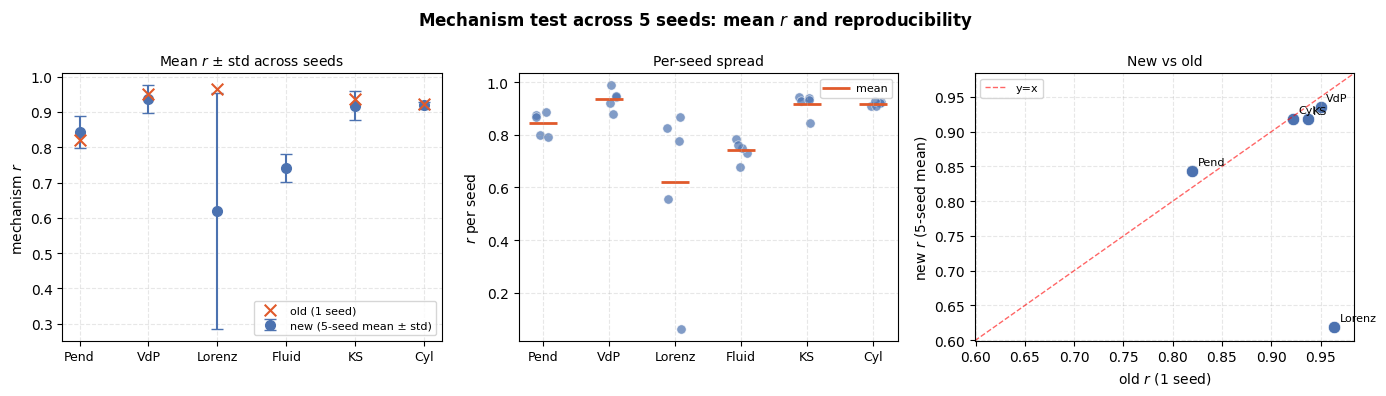

Saved mechanism_5seed.png  (min across-seed mean r = 0.619)


In [31]:
# ── Figure: 5-seed mechanism summary ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

order = ['Pendulum','Van der Pol','Lorenz','FluidFlowBox',
         'Kuramoto-Sivashinsky','Cylinder']
short = ['Pend','VdP','Lorenz','Fluid','KS','Cyl']

def _seed_vals(name):
    v = np.array([ck[name][k] for k in sorted(ck.get(name, {}))], float)
    return v[np.isfinite(v)]

seed_vals = [_seed_vals(n) for n in order]
means = np.array([v.mean()         if len(v)     else np.nan for v in seed_vals])
stds  = np.array([v.std(ddof=1)    if len(v) > 1 else 0.0    for v in seed_vals])
olds  = np.array([OLD.get(n, np.nan) for n in order])
x     = np.arange(len(order))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(r"Mechanism test across 5 seeds: mean $r$ and reproducibility",
             fontsize=12, fontweight='bold')

# Panel 1: per-system mean ± std(seed), with old 1-seed markers
axes[0].errorbar(x, means, yerr=stds, fmt='o', color='#4C72B0',
                 capsize=4, ms=7, lw=1.5, label='new (5-seed mean ± std)')
axes[0].scatter(x, olds, marker='x', s=70, color='#E05A2B',
                zorder=5, label='old (1 seed)')
axes[0].set_xticks(x); axes[0].set_xticklabels(short, fontsize=9)
axes[0].set_ylabel(r"mechanism $r$", fontsize=10)
axes[0].set_title(r"Mean $r$ $\pm$ std across seeds", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel 2: every seed as a jittered dot (raw spread)
rng = np.random.default_rng(0)
for i, v in enumerate(seed_vals):
    jit = rng.uniform(-0.12, 0.12, size=len(v))
    axes[1].scatter(np.full(len(v), i) + jit, v, alpha=0.7, s=45,
                    color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[1].scatter(x, means, marker='_', s=400, color='#E05A2B',
                linewidth=2, label='mean')
axes[1].set_xticks(x); axes[1].set_xticklabels(short, fontsize=9)
axes[1].set_ylabel(r"$r$ per seed", fontsize=10)
axes[1].set_title("Per-seed spread", fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(True, linestyle='--', alpha=0.3)

# Panel 3: new 5-seed mean vs old 1-seed value (does the story change?)
m = np.isfinite(means) & np.isfinite(olds)
axes[2].scatter(olds[m], means[m], s=80, color='#4C72B0',
                edgecolor='white', linewidth=0.5)
for xi, yi, lab in zip(olds[m], means[m], np.array(short)[m]):
    axes[2].annotate(lab, (xi, yi), fontsize=8,
                     xytext=(4, 4), textcoords='offset points')
lims = [min(olds[m].min(), means[m].min()) - 0.02,
        max(olds[m].max(), means[m].max()) + 0.02]
axes[2].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel(r"old $r$ (1 seed)", fontsize=10)
axes[2].set_ylabel(r"new $r$ (5-seed mean)", fontsize=10)
axes[2].set_title("New vs old", fontsize=10)
axes[2].legend(fontsize=8); axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['mechanism_5seed.png',
              f'{OUTPUT_DIR}/mechanism_5seed.png',
              f'{FIG_DIR}/mechanism_5seed.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()

# Store for the summary / paper
mech_5seed = dict(
    systems=order,
    seed_vals=[v.tolist() for v in seed_vals],
    means=means, stds=stds, olds=olds,
    min_mean=float(np.nanmin(means)),
)
print(f"Saved mechanism_5seed.png  "
      f"(min across-seed mean r = {np.nanmin(means):.3f})")

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# Table 6 (corrected): mechanism r, 5 seeds per system — CHECKPOINT-FIRST.
#
# If the checkpoint is already complete, this cell just loads it and prints the
# table — NO retraining, and no dependency on the upstream cells. So after one
# full run you can restart the kernel and run only this cell to see the numbers.
# If the checkpoint is only partial, it retrains just the MISSING seeds (the
# resume guard that the previous version of this cell was missing), which does
# need the upstream pipeline (trainers/data) to have run.
# Checkpoint: {OUTPUT_DIR}/mechanism_5seed_checkpoint.json
# ══════════════════════════════════════════════════════════════════════════════
import os, json, numpy as np

N_SEEDS_MECH = 5
EXPECTED = ['Pendulum', 'Van der Pol', 'Lorenz', 'FluidFlowBox',
            'Kuramoto-Sivashinsky', 'Cylinder']
OLD = {'Pendulum': 0.820, 'Van der Pol': 0.950, 'Lorenz': 0.964,
       'Cylinder': 0.922, 'Kuramoto-Sivashinsky': 0.937}

# Resolve the checkpoint path even if upstream cells haven't defined OUTPUT_DIR
try:
    _OUT = OUTPUT_DIR
except NameError:
    _OUT = "."
CKPT = f"{_OUT}/mechanism_5seed_checkpoint.json"

ck = json.load(open(CKPT)) if os.path.exists(CKPT) else {}

def _ms(vals):
    v = np.array([x for x in vals if x == x], float)
    if len(v) == 0:
        return float('nan'), float('nan'), 0
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0), len(v)

def _report():
    print("\n" + "=" * 78)
    print("TABLE 6 (corrected) — mechanism r, mean ± std ACROSS SEEDS")
    print("=" * 78)
    print(f"{'System':<24}{'new mean r':>11}{'std(seed)':>11}{'n':>4}"
          f"{'old(1-seed)':>13}")
    print("-" * 78)
    mins = []
    for name in EXPECTED:
        m, sd, n = _ms(list(ck.get(name, {}).values()))
        if m == m:
            mins.append(m)
        print(f"{name:<24}{m:>11.3f}{sd:>11.3f}{n:>4}"
              f"{OLD.get(name, float('nan')):>13.3f}")
    print("=" * 78)
    if mins:
        print(f"min across-seed mean r = {min(mins):.3f}")

_complete = all(len(ck.get(name, {})) >= N_SEEDS_MECH for name in EXPECTED)

if _complete:
    print(f"\u2713 Loaded complete checkpoint from {CKPT}")
    print("  (all systems \u00d7 5 seeds cached \u2014 no retraining needed)")
    _report()
else:
    missing = {n: N_SEEDS_MECH - len(ck.get(n, {}))
               for n in EXPECTED if len(ck.get(n, {})) < N_SEEDS_MECH}
    print(f"Checkpoint incomplete \u2014 missing seeds: {missing}")
    print("Computing only the missing seeds (needs the upstream cells to have run).")
    import torch

    def _np(a):
        try:
            return a.detach().cpu().numpy()
        except AttributeError:
            return np.asarray(a)

    PEND_XS  = _np(X_tr_n[:, :-1, :].reshape(-1, 2))[:200]
    VDP_XS   = _np(vdp_n[:70, :VDP_TRAIN].reshape(-1, 2))[:200]
    LZ_XS    = _np(lz_n[:40, :1000].reshape(-1, 3))[:200]
    CYL_XS   = _np(X_train_n).T[:100]
    KS_XS    = _np(data_n)[:150]
    FLUID_XS = _np(X_f_tr_n[:, :-1, :].reshape(-1, 3))[:200]

    def _mech_r(geo, ae, latent, xs, ns, label):
        K_np = geo.K.detach().cpu().numpy()
        m = run_mechanism_test(koop=geo, ae=ae, K_np=K_np, latent_dim=latent,
                               x_samples=xs, label=label, n_samples=ns)
        return float(np.mean(m['correlations']))

    def _seed_pendulum(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = AE(2, P_LATENT, hidden=64).to(device)
        geo = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
        train_pendulum(ae, geo, f"Pend-Geo-s{s}", use_geo=True)
        return _mech_r(geo, ae, P_LATENT, PEND_XS, 200, f"Pendulum s{s}")

    def _seed_vdp(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = AE(2, VDP_LATENT).to(device)
        geo = KoopmanVdP(VDP_LATENT, use_geo=True).to(device)
        train_vdp(ae, geo, f"VdP-Geo-s{s}", use_geo=True)
        return _mech_r(geo, ae, VDP_LATENT, VDP_XS, 200, f"VdP s{s}")

    def _seed_lorenz(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = AE(3, LZ_LATENT).to(device)
        geo = KoopmanLorenz(LZ_LATENT, use_geo=True).to(device)
        train_lorenz(ae, geo, f"Lz-Geo-s{s}", use_geo=True)
        return _mech_r(geo, ae, LZ_LATENT, LZ_XS, 200, f"Lorenz s{s}")

    def _seed_cylinder(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = cyl_ae(C_LATENT)
        geo = cyl_koop(C_LATENT, geo=True)
        train_model(ae, geo, cx_t, cx_tp1, use_geo=True, label=f"Cyl-Geo-s{s}",
                    epochs_p1=500, epochs_p2=3000, rollout_steps=20, lam_geo=0.0)
        return _mech_r(geo, ae, C_LATENT, CYL_XS, 100, f"Cylinder s{s}")

    def _seed_ks(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = AE(KS_N, KS_LATENT).to(device)
        geo = KoopmanKS(KS_LATENT, use_geo=True).to(device)
        train_ks(ae, geo, f"KS-Geo-s{s}", use_geo=True)
        return _mech_r(geo, ae, KS_LATENT, KS_XS, 150, f"KS s{s}")

    def _seed_fluid(s):
        torch.manual_seed(s); np.random.seed(s)
        ae  = AE(3, F_LATENT, hidden=128).to(device)
        geo = KoopmanCore(F_LATENT, use_geo=True).to(device)
        train_model(ae, geo, f_xt, f_xtp1, use_geo=True, label=f"Fluid-Geo-s{s}",
                    epochs_p1=1000, epochs_p2=2000, rollout_steps=20, lam_geo=0.0)
        return _mech_r(geo, ae, F_LATENT, FLUID_XS, 200, f"FluidFlowBox s{s}")

    MECH_SYS = [
        ('Pendulum',             _seed_pendulum),
        ('Van der Pol',          _seed_vdp),
        ('Lorenz',               _seed_lorenz),
        ('FluidFlowBox',         _seed_fluid),
        ('Kuramoto-Sivashinsky', _seed_ks),
        ('Cylinder',             _seed_cylinder),   # slowest (retrains 5x @3000 ep)
    ]

    for name, fn in MECH_SYS:
        ck.setdefault(name, {})
        for s in range(N_SEEDS_MECH):
            if str(s) in ck[name]:                       # <-- resume guard
                print(f"{name} s{s}: cached \u2014 skip"); continue
            print(f"\n{'='*56}\n{name} \u2014 mechanism seed {s}\n{'='*56}")
            try:
                ck[name][str(s)] = fn(s)
                print(f"   -> r = {ck[name][str(s)]:.4f}")
            except Exception as e:
                print(f"   seed {s} FAILED: {repr(e)[:120]}")
                ck[name][str(s)] = float('nan')
            json.dump(ck, open(CKPT, 'w'))             # save after every seed

    _report()


✓ Loaded complete checkpoint from /content/drive/MyDrive/Koopman/outputs/mechanism_5seed_checkpoint.json
  (all systems × 5 seeds cached — no retraining needed)

TABLE 6 (corrected) — mechanism r, mean ± std ACROSS SEEDS
System                   new mean r  std(seed)   n  old(1-seed)
------------------------------------------------------------------------------
Pendulum                      0.844      0.045   5        0.820
Van der Pol                   0.935      0.039   5        0.950
Lorenz                        0.619      0.333   5        0.964
FluidFlowBox                  0.741      0.040   5          nan
Kuramoto-Sivashinsky          0.918      0.040   5        0.937
Cylinder                      0.918      0.009   5        0.922
min across-seed mean r = 0.619
